## Load modules

## Import packages 

In [2]:
import numpy as np
import pandas as pd
import math as math
import matplotlib.pyplot as plt
import subprocess
import os
import scipy.stats as stats
from collections import Counter
import seaborn as sns


plt.rcParams["font.sans-serif"]='Arial'

import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

Import your sample datasheet. If you have already run part of the notebook, some additional columns might be there.

In [7]:
sgRNA_df = pd.read_csv('./sgRNAs_annot_wcounts_env_screen.csv', sep=',', index_col=0)

In [8]:
list(sgRNA_df.columns)

['Gene',
 'alias',
 'SgRNA',
 'Barcode',
 'control',
 'strand',
 'atg_dist',
 'B_mismatch',
 'dist_TSS',
 'abs_TSS_dist',
 'GC_content',
 'ATC_control_T0_1',
 'ATC_control_T0_2',
 'ATC_control_T0_3',
 'NoATC_control_T0_1',
 'NoATC_control_T0_2',
 'NoATC_control_T0_3',
 'ATC_YPD_T3_1',
 'ATC_YPD_T3_2',
 'ATC_YPD_T3_3',
 'NoATC_YPD_T3_1',
 'NoATC_YPD_T3_2',
 'NoATC_YPD_T3_3',
 'ATC_LAC_T3_1',
 'ATC_LAC_T3_2',
 'ATC_LAC_T3_3',
 'NoATC_LAC_T3_1',
 'NoATC_LAC_T3_2',
 'NoATC_LAC_T3_3',
 'ATC_GLY_T3_1',
 'ATC_GLY_T3_2',
 'ATC_GLY_T3_3',
 'NoATC_GLY_T3_1',
 'NoATC_GLY_T3_2',
 'NoATC_GLY_T3_3',
 'ATC_ACE_T3_1',
 'ATC_ACE_T3_2',
 'ATC_ACE_T3_3',
 'NoATC_ACE_T3_1',
 'NoATC_ACE_T3_2',
 'NoATC_ACE_T3_3',
 'ATC_NACL_T3_1',
 'ATC_NACL_T3_2',
 'ATC_NACL_T3_3',
 'NoATC_NACL_T3_1',
 'NoATC_NACL_T3_2',
 'NoATC_NACL_T3_3',
 'ATC_SORB_T3_1',
 'ATC_SORB_T3_2',
 'ATC_SORB_T3_3',
 'NoATC_SORB_T3_1',
 'NoATC_SORB_T3_2',
 'NoATC_SORB_T3_3',
 'ATC_LOPH_T3_1',
 'ATC_LOPH_T3_2',
 'ATC_LOPH_T3_3',
 'NoATC_LOPH_T3_1

## Go from raw counts to frequencies

In [9]:
raw_count_col = ['ATC_control_T0_1', 'ATC_control_T0_2', 'ATC_control_T0_3',
                 'NoATC_control_T0_1', 'NoATC_control_T0_2', 'NoATC_control_T0_3',
                 'ATC_YPD_T3_1', 'ATC_YPD_T3_2', 'ATC_YPD_T3_3',
                 'NoATC_YPD_T3_1', 'NoATC_YPD_T3_2', 'NoATC_YPD_T3_3',
                 'ATC_LAC_T3_1', 'ATC_LAC_T3_2', 'ATC_LAC_T3_3',
                 'NoATC_LAC_T3_1', 'NoATC_LAC_T3_2', 'NoATC_LAC_T3_3',
                 'ATC_GLY_T3_1', 'ATC_GLY_T3_2', 'ATC_GLY_T3_3',
                 'NoATC_GLY_T3_1', 'NoATC_GLY_T3_2', 'NoATC_GLY_T3_3',
                 'ATC_ACE_T3_1', 'ATC_ACE_T3_2', 'ATC_ACE_T3_3',
                 'NoATC_ACE_T3_1', 'NoATC_ACE_T3_2', 'NoATC_ACE_T3_3',
                 'ATC_NACL_T3_1', 'ATC_NACL_T3_2', 'ATC_NACL_T3_3',
                 'NoATC_NACL_T3_1', 'NoATC_NACL_T3_2', 'NoATC_NACL_T3_3',
                 'ATC_SORB_T3_1', 'ATC_SORB_T3_2', 'ATC_SORB_T3_3',
                 'NoATC_SORB_T3_1', 'NoATC_SORB_T3_2', 'NoATC_SORB_T3_3',
                 'ATC_LOPH_T3_1', 'ATC_LOPH_T3_2', 'ATC_LOPH_T3_3',
                 'NoATC_LOPH_T3_1', 'NoATC_LOPH_T3_2', 'NoATC_LOPH_T3_3',
                 'ATC_SDS_T3_1', 'ATC_SDS_T3_2', 'ATC_SDS_T3_3',
                 'NoATC_SDS_T3_1', 'NoATC_SDS_T3_2', 'NoATC_SDS_T3_3',
                 'ATC_5FC_T3_1', 'ATC_5FC_T3_2', 'ATC_5FC_T3_3',
                 'NoATC_5FC_T3_1', 'NoATC_5FC_T3_2', 'NoATC_5FC_T3_3',
                 'ATC_TUN_T3_1', 'ATC_TUN_T3_2', 'ATC_TUN_T3_3',
                 'NoATC_TUN_T3_1', 'NoATC_TUN_T3_2', 'NoATC_TUN_T3_3',
                 'ATC_MMS_T3_1', 'ATC_MMS_T3_2', 'ATC_MMS_T3_3',
                 'NoATC_MMS_T3_1', 'NoATC_MMS_T3_2', 'NoATC_MMS_T3_3']

ATC_control_T0_1 15 116.0 34
ATC_control_T0_2 20 113.4 39
ATC_control_T0_3 19 153.3 30
NoATC_control_T0_1 22 115.0 33
NoATC_control_T0_2 14 123.80000000000001 32
NoATC_control_T0_3 12 87.0 34


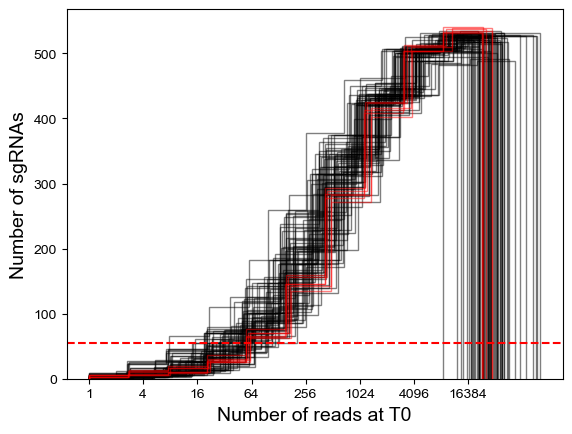

In [10]:
for col in raw_count_col: 
    if 'T0' in col:
        print(col, 553-len(sgRNA_df[col].dropna()), np.percentile(sgRNA_df[col].dropna(),10), 553-len(sgRNA_df[sgRNA_df[col]>=32]))
        plt.hist(np.log2(sgRNA_df[col].dropna()), histtype='step', cumulative=True, color='r', alpha=0.5, zorder=9)

        
    if 'T3' in col:
        plt.hist(np.log2(sgRNA_df[col].dropna()), histtype='step', cumulative=True, color='k', alpha=0.5)
        
      
        
plt.xticks([0,2,4,6,8,10,12,14], [str(2**x) for x in [0,2,4,6,8,10,12,14]])

plt.xlabel('Number of reads at T0', fontsize=14)
plt.ylabel('Number of sgRNAs', fontsize=14)


plt.axhline(55,color='r', linestyle='--')

In [15]:
freq_col_list = []

for col in raw_count_col:
    freq_col = ('freq_'+col)
    sgRNA_df[('freq_'+col)] = ((sgRNA_df[col].fillna(value=0))+1)/(sgRNA_df[col].sum()+len(sgRNA_df))
    freq_col_list.append(freq_col)
    # now we do this for all read count columns in the dataset
sgRNA_df
# go from raw read count for each sgRNA to their relative abundance
# we add one to every count to avoid issues with 0 values when computing log2 fold change downstream
# to take this into account, we add 1*n_sgrna to the denominator so the total of fractions remains 1

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,freq_ATC_TUN_T3_3,freq_NoATC_TUN_T3_1,freq_NoATC_TUN_T3_2,freq_NoATC_TUN_T3_3,freq_ATC_MMS_T3_1,freq_ATC_MMS_T3_2,freq_ATC_MMS_T3_3,freq_NoATC_MMS_T3_1,freq_NoATC_MMS_T3_2,freq_NoATC_MMS_T3_3
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,0,+,112.0,no,-9.0,9.0,...,0.000464,0.000508,0.000546,0.000568,0.000603,4.286082e-04,0.000516,0.000294,0.000500,0.000581
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,0,-,45.0,no,58.0,58.0,...,0.000904,0.000732,0.000699,0.001117,0.000953,9.151878e-04,0.000738,0.001045,0.001146,0.000972
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,0,-,38.0,no,65.0,65.0,...,0.000030,0.000020,0.000019,0.000034,0.000008,3.706368e-05,0.000040,0.000041,0.000021,0.000042
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,0,+,288.0,no,-185.0,185.0,...,0.000388,0.000326,0.000227,0.000439,0.000348,3.497291e-04,0.000334,0.000427,0.000389,0.000355
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,0,-,177.0,no,-89.0,89.0,...,0.000500,0.000604,0.000433,0.000478,0.000551,4.884803e-04,0.000592,0.000553,0.000547,0.000480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,1,NaN,NaN,no,NaN,NaN,...,0.002955,0.003080,0.002474,0.002750,0.003413,3.668354e-03,0.003686,0.004619,0.004425,0.004423
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,1,NaN,NaN,no,NaN,NaN,...,0.001297,0.001525,0.001451,0.001596,0.001470,1.400817e-03,0.001462,0.001807,0.001609,0.001651
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,1,NaN,NaN,no,NaN,NaN,...,0.005303,0.007257,0.007608,0.007767,0.006083,5.998614e-03,0.005826,0.005018,0.005288,0.005074
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,1,NaN,NaN,no,NaN,NaN,...,0.000308,0.000343,0.000262,0.000230,0.000492,5.331468e-04,0.000384,0.000273,0.000282,0.000219


Text(0, 0.5, 'Freq')

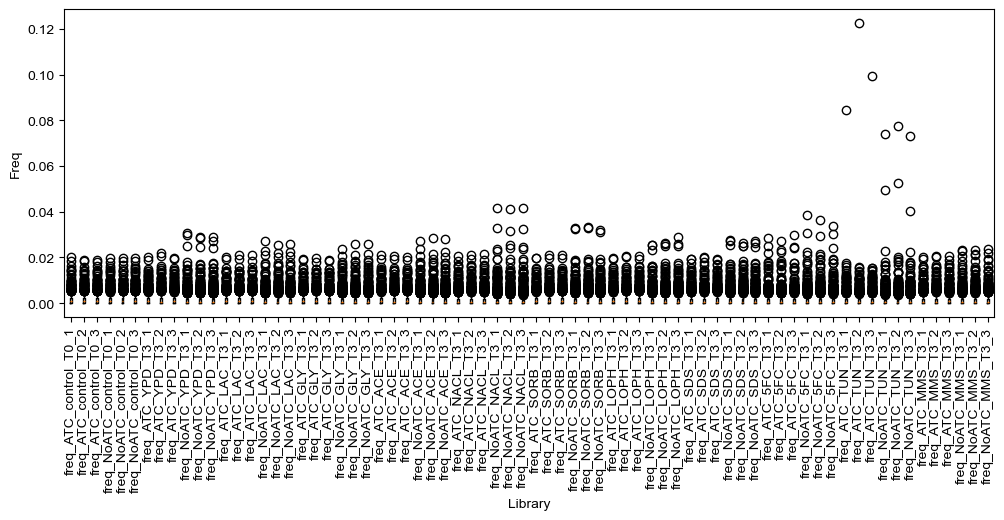

In [16]:
plt.figure(figsize=(12,4))

# let's also look at the distribution of raw abundances for each library

x=0

for col in freq_col_list:
    # print the number of reads for each library
    
    plt.boxplot(sgRNA_df[col].dropna(), positions=[x])
    x+=1
    


plt.xticks(range(0, len(freq_col_list)), freq_col_list, rotation=90)
# label x-ticks

plt.xlabel('Library')
plt.ylabel('Freq')
# format axis labels

In [17]:
to_log2_col_list = [x for x in freq_col_list if 'T3' in x]
to_log2_col_list

['freq_ATC_YPD_T3_1',
 'freq_ATC_YPD_T3_2',
 'freq_ATC_YPD_T3_3',
 'freq_NoATC_YPD_T3_1',
 'freq_NoATC_YPD_T3_2',
 'freq_NoATC_YPD_T3_3',
 'freq_ATC_LAC_T3_1',
 'freq_ATC_LAC_T3_2',
 'freq_ATC_LAC_T3_3',
 'freq_NoATC_LAC_T3_1',
 'freq_NoATC_LAC_T3_2',
 'freq_NoATC_LAC_T3_3',
 'freq_ATC_GLY_T3_1',
 'freq_ATC_GLY_T3_2',
 'freq_ATC_GLY_T3_3',
 'freq_NoATC_GLY_T3_1',
 'freq_NoATC_GLY_T3_2',
 'freq_NoATC_GLY_T3_3',
 'freq_ATC_ACE_T3_1',
 'freq_ATC_ACE_T3_2',
 'freq_ATC_ACE_T3_3',
 'freq_NoATC_ACE_T3_1',
 'freq_NoATC_ACE_T3_2',
 'freq_NoATC_ACE_T3_3',
 'freq_ATC_NACL_T3_1',
 'freq_ATC_NACL_T3_2',
 'freq_ATC_NACL_T3_3',
 'freq_NoATC_NACL_T3_1',
 'freq_NoATC_NACL_T3_2',
 'freq_NoATC_NACL_T3_3',
 'freq_ATC_SORB_T3_1',
 'freq_ATC_SORB_T3_2',
 'freq_ATC_SORB_T3_3',
 'freq_NoATC_SORB_T3_1',
 'freq_NoATC_SORB_T3_2',
 'freq_NoATC_SORB_T3_3',
 'freq_ATC_LOPH_T3_1',
 'freq_ATC_LOPH_T3_2',
 'freq_ATC_LOPH_T3_3',
 'freq_NoATC_LOPH_T3_1',
 'freq_NoATC_LOPH_T3_2',
 'freq_NoATC_LOPH_T3_3',
 'freq_ATC_SDS_T

In [18]:
drug_list = ['YPD', 'LAC', 'GLY', 'ACE', 'NACL', 'SORB','LOPH', 'SDS', '5FC', 'TUN', 'MMS']

rep_list = ['1','2','3']


log2_col_list = []

count_col=0

for drug in drug_list:
    for rep in rep_list:
        ref_col_noATC = 'freq_NoATC_control_T0_'+rep
        ref_col_ATC = 'freq_ATC_control_T0_'+rep
        count_col+=2

        strain_col_noATC = 'freq_NoATC_'+drug+'_T3_'+rep
        log2_col_name_noATC = 'log2fc_NoATC_'+drug+'_T3_'+rep
        #print(ref_col_noATC,strain_col_noATC, log2_col_name_noATC)

        strain_col_ATC = 'freq_ATC_'+drug+'_T3_'+rep
        log2_col_name_ATC = 'log2fc_ATC_'+drug+'_T3_'+rep
        #print(ref_col_ATC,strain_col_ATC, log2_col_name_ATC)

        log2_col_list.append(log2_col_name_noATC)
        log2_col_list.append(log2_col_name_ATC)

        sgRNA_df[log2_col_name_noATC] = np.log2(sgRNA_df[strain_col_noATC]) - np.log2(sgRNA_df[ref_col_noATC])
        sgRNA_df[log2_col_name_ATC] = np.log2(sgRNA_df[strain_col_ATC]) - np.log2(sgRNA_df[ref_col_ATC])
                
print(count_col)
sgRNA_df

66


,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_NoATC_TUN_T3_2,log2fc_ATC_TUN_T3_2,log2fc_NoATC_TUN_T3_3,log2fc_ATC_TUN_T3_3,log2fc_NoATC_MMS_T3_1,log2fc_ATC_MMS_T3_1,log2fc_NoATC_MMS_T3_2,log2fc_ATC_MMS_T3_2,log2fc_NoATC_MMS_T3_3,log2fc_ATC_MMS_T3_3
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,0,+,112.0,no,-9.0,9.0,...,0.294997,-0.090841,0.385270,0.038776,-0.509862,0.373648,0.166920,0.031861,0.416678,0.192136
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,0,-,45.0,no,58.0,58.0,...,-0.287748,1.072631,0.465747,0.150213,0.376142,0.293432,0.425689,0.073258,0.265257,-0.142129
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,0,-,38.0,no,65.0,65.0,...,-0.786614,0.254405,-0.232039,-0.314550,0.084518,-1.496128,-0.588252,0.133102,0.076616,0.092242
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,0,+,288.0,no,-185.0,185.0,...,-0.819289,-0.505976,0.353563,-0.094056,0.191906,0.041432,-0.040621,-0.128205,0.048587,-0.310612
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,0,-,177.0,no,-89.0,89.0,...,-0.181515,-0.438478,-0.057215,0.204353,0.192592,0.221018,0.155715,-0.069508,-0.050168,0.447479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,1,NaN,NaN,no,NaN,NaN,...,-0.638556,-0.111713,-0.474300,-0.260381,0.381014,-0.138502,0.200023,-0.019899,0.211595,0.058451
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,1,NaN,NaN,no,NaN,NaN,...,-0.010796,0.071226,-0.006162,-0.080567,0.267321,-0.111078,0.138167,0.066833,0.042616,0.091680
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,1,NaN,NaN,no,NaN,NaN,...,0.282434,-0.076560,0.314096,-0.149145,-0.268112,-0.064953,-0.242368,0.037946,-0.300087,-0.013327
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,1,NaN,NaN,no,NaN,NaN,...,-0.955351,-0.048298,-1.064056,-0.537108,-0.499879,0.060127,-0.847816,0.276477,-1.134296,-0.218492


In [19]:
def set_to_nan(log2_fc, count, threshold):
    # Function to apply initial abundance filter to columns: will change values in log2fc for a sgRNA
    # to nan if the value in the count col is below or equal to threshold. Can be applied to a column
    # using a lambda function
    
    #print(log2_fc, count, threshold)
    # debugging print call
    
    if count <= threshold:
        return np.nan
    elif np.isnan(count)==True:
        return np.nan
    else:
        return log2_fc

In [20]:
drug_list = ['YPD', 'LAC', 'GLY', 'ACE', 'NACL', 'SORB','LOPH', 'SDS', '5FC', 'TUN', 'MMS']

rep_list = ['1','2','3']


log2_col_list = []

count_col=0

for drug in drug_list:
    for rep in rep_list:
        ref_col_noATC = 'freq_NoATC_control_T0_'+rep
        ref_col_ATC = 'freq_ATC_control_T0_'+rep
        count_col+=2

        strain_col_noATC = 'freq_NoATC_'+drug+'_T3_'+rep
        log2_col_name_noATC = 'log2fc_NoATC_'+drug+'_T3_'+rep
        #print(ref_col_noATC,strain_col_noATC, log2_col_name_noATC)

        strain_col_ATC = 'freq_ATC_'+drug+'_T3_'+rep
        log2_col_name_ATC = 'log2fc_ATC_'+drug+'_T3_'+rep
        #print(ref_col_ATC,strain_col_ATC, log2_col_name_ATC)

        log2_col_list.append(log2_col_name_noATC)
        log2_col_list.append(log2_col_name_ATC)

        sgRNA_df[log2_col_name_noATC] = np.log2(sgRNA_df[strain_col_noATC]) - np.log2(sgRNA_df[ref_col_noATC])
        sgRNA_df[log2_col_name_noATC] = sgRNA_df.apply(lambda x: set_to_nan(x[log2_col_name_noATC], x[('NoATC_control_T0_'+rep)], 50),axis=1)
        print('dropped '+str(553-len(sgRNA_df[log2_col_name_noATC].dropna()))+' for column '+log2_col_name_noATC)
               
        
        sgRNA_df[log2_col_name_ATC] = np.log2(sgRNA_df[strain_col_ATC]) - np.log2(sgRNA_df[ref_col_ATC])
        sgRNA_df[log2_col_name_ATC] = sgRNA_df.apply(lambda x: set_to_nan(x[log2_col_name_ATC], x[('ATC_control_T0_'+rep)], 50),axis=1)
        print('dropped '+str(553-len(sgRNA_df[log2_col_name_ATC].dropna()))+' for column '+log2_col_name_ATC)

                
print(count_col)
sgRNA_df

dropped 46 for column log2fc_NoATC_YPD_T3_1
dropped 42 for column log2fc_ATC_YPD_T3_1
dropped 39 for column log2fc_NoATC_YPD_T3_2
dropped 44 for column log2fc_ATC_YPD_T3_2
dropped 44 for column log2fc_NoATC_YPD_T3_3
dropped 37 for column log2fc_ATC_YPD_T3_3
dropped 46 for column log2fc_NoATC_LAC_T3_1
dropped 42 for column log2fc_ATC_LAC_T3_1
dropped 39 for column log2fc_NoATC_LAC_T3_2
dropped 44 for column log2fc_ATC_LAC_T3_2
dropped 44 for column log2fc_NoATC_LAC_T3_3
dropped 37 for column log2fc_ATC_LAC_T3_3
dropped 46 for column log2fc_NoATC_GLY_T3_1
dropped 42 for column log2fc_ATC_GLY_T3_1
dropped 39 for column log2fc_NoATC_GLY_T3_2
dropped 44 for column log2fc_ATC_GLY_T3_2
dropped 44 for column log2fc_NoATC_GLY_T3_3
dropped 37 for column log2fc_ATC_GLY_T3_3
dropped 46 for column log2fc_NoATC_ACE_T3_1
dropped 42 for column log2fc_ATC_ACE_T3_1
dropped 39 for column log2fc_NoATC_ACE_T3_2
dropped 44 for column log2fc_ATC_ACE_T3_2
dropped 44 for column log2fc_NoATC_ACE_T3_3
dropped 37

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_NoATC_TUN_T3_2,log2fc_ATC_TUN_T3_2,log2fc_NoATC_TUN_T3_3,log2fc_ATC_TUN_T3_3,log2fc_NoATC_MMS_T3_1,log2fc_ATC_MMS_T3_1,log2fc_NoATC_MMS_T3_2,log2fc_ATC_MMS_T3_2,log2fc_NoATC_MMS_T3_3,log2fc_ATC_MMS_T3_3
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,0,+,112.0,no,-9.0,9.0,...,0.294997,-0.090841,0.385270,0.038776,-0.509862,0.373648,0.166920,0.031861,0.416678,0.192136
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,0,-,45.0,no,58.0,58.0,...,-0.287748,1.072631,0.465747,0.150213,0.376142,0.293432,0.425689,0.073258,0.265257,-0.142129
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,0,-,38.0,no,65.0,65.0,...,NaN,NaN,NaN,-0.314550,NaN,NaN,NaN,NaN,NaN,0.092242
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,0,+,288.0,no,-185.0,185.0,...,-0.819289,-0.505976,0.353563,-0.094056,0.191906,0.041432,-0.040621,-0.128205,0.048587,-0.310612
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,0,-,177.0,no,-89.0,89.0,...,-0.181515,-0.438478,-0.057215,0.204353,0.192592,0.221018,0.155715,-0.069508,-0.050168,0.447479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,1,NaN,NaN,no,NaN,NaN,...,-0.638556,-0.111713,-0.474300,-0.260381,0.381014,-0.138502,0.200023,-0.019899,0.211595,0.058451
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,1,NaN,NaN,no,NaN,NaN,...,-0.010796,0.071226,-0.006162,-0.080567,0.267321,-0.111078,0.138167,0.066833,0.042616,0.091680
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,1,NaN,NaN,no,NaN,NaN,...,0.282434,-0.076560,0.314096,-0.149145,-0.268112,-0.064953,-0.242368,0.037946,-0.300087,-0.013327
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,1,NaN,NaN,no,NaN,NaN,...,-0.955351,-0.048298,-1.064056,-0.537108,-0.499879,0.060127,-0.847816,0.276477,-1.134296,-0.218492


In [22]:
condition_list = ['YPD', 'LAC', 'GLY', 'ACE', 'NACL', 'SORB','LOPH', 'SDS', '5FC', 'TUN', 'MMS']


In [23]:
for condition in condition_list:
    for induction in ['ATC', 'NoATC']:
        median_col_name = 'median_log2fc_'+induction+'_'+condition
        col_start='log2fc_'+induction+'_'+condition
        
        
        sgRNA_df[median_col_name] = sgRNA_df[[(col_start+'_T3_1'),(col_start+'_T3_2'),(col_start+'_T3_3')]].median(axis=1)

In [24]:
for condition in condition_list:
    for induction in ['ATC', 'NoATC']:
        median_col_name = 'median_log2fc_'+induction+'_'+condition
        col_start='log2fc_'+induction+'_'+condition
        
        n_nans = sgRNA_df[[(col_start+'_T3_1'),(col_start+'_T3_2'),(col_start+'_T3_3')]].isnull().sum(axis=1)
        above_0_nan = list(n_nans[n_nans>0].index)
        
        for row in above_0_nan:
            sgRNA_df.at[row,median_col_name]=np.nan
        
        

In [25]:
log2_col_names = ['OFF YPD R1',
                     'OFF YPD R2',
                     'OFF YPD R3',
                     'ON YPD R1',
                     'ON YPD R2',
                     'ON YPD R3',
                     'OFF LAC R1',
                     'OFF LAC R2',
                     'OFF LAC R3',
                     'ON LAC R1',
                     'ON LAC R2',
                     'ON LAC R3',
                     'OFF GLY R1',
                     'OFF GLY R2',
                     'OFF GLY R3',
                     'ON GLY R1',
                     'ON GLY R2',
                     'ON GLY R3',
                     'OFF ACE R1',
                     'OFF ACE R2',
                     'OFF ACE R3',
                     'ON ACE R1',
                     'ON ACE R2',
                     'ON ACE R3',
                     'OFF NACL R1',
                     'OFF NACL R2',
                     'OFF NACL R3',
                     'ON NACL R1',
                     'ON NACL R2',
                     'ON NACL R3',
                     'OFF SORB R1',
                     'OFF SORB R2',
                     'OFF SORB R3',
                     'ON SORB R1',
                     'ON SORB R2',
                     'ON SORB R3',
                     'OFF LOPH R1',
                     'OFF LOPH R2',
                     'OFF LOPH R3',
                     'ON LOPH R1',
                     'ON LOPH R2',
                     'ON LOPH R3',
                     'OFF SDS R1',
                     'OFF SDS R2',
                     'OFF SDS R3',
                     'ON SDS R1',
                     'ON SDS R2',
                     'ON SDS R3',
                     'OFF 5FC R1',
                     'OFF 5FC R2',
                     'OFF 5FC R3',
                     'ON 5FC R1',
                     'ON 5FC R2',
                     'ON 5FC R3',
                     'OFF TUN R1',
                     'OFF TUN R2',
                     'OFF TUN R3',
                     'ON TUN R1',
                     'ON TUN R2',
                     'ON TUN R3',
                     'OFF MMS R1',
                     'OFF MMS R2',
                     'OFF MMS R3',
                     'ON MMS R1',
                     'ON MMS R2',
                     'ON MMS R3']


In [26]:
log2_col_list_mod = ['log2fc_ATC_YPD_T3_1',
                     'log2fc_ATC_YPD_T3_2',
                     'log2fc_ATC_YPD_T3_3',
                     'log2fc_NoATC_YPD_T3_1',
                     'log2fc_NoATC_YPD_T3_2',
                     'log2fc_NoATC_YPD_T3_3',
                     'log2fc_ATC_LAC_T3_1',
                     'log2fc_ATC_LAC_T3_2',
                     'log2fc_ATC_LAC_T3_3',
                     'log2fc_NoATC_LAC_T3_1',
                     'log2fc_NoATC_LAC_T3_2',
                     'log2fc_NoATC_LAC_T3_3',
                     'log2fc_ATC_GLY_T3_1',
                     'log2fc_ATC_GLY_T3_2',
                     'log2fc_ATC_GLY_T3_3',
                     'log2fc_NoATC_GLY_T3_1',
                     'log2fc_NoATC_GLY_T3_2',
                     'log2fc_NoATC_GLY_T3_3',
                     'log2fc_ATC_ACE_T3_1',
                     'log2fc_ATC_ACE_T3_2',
                     'log2fc_ATC_ACE_T3_3',
                     'log2fc_NoATC_ACE_T3_1',
                     'log2fc_NoATC_ACE_T3_2',
                     'log2fc_NoATC_ACE_T3_3',
                     'log2fc_ATC_NACL_T3_1',
                     'log2fc_ATC_NACL_T3_2',
                     'log2fc_ATC_NACL_T3_3',
                     'log2fc_NoATC_NACL_T3_1',
                     'log2fc_NoATC_NACL_T3_2',
                     'log2fc_NoATC_NACL_T3_3',
                     'log2fc_ATC_SORB_T3_1',
                     'log2fc_ATC_SORB_T3_2',
                     'log2fc_ATC_SORB_T3_3',
                     'log2fc_NoATC_SORB_T3_1',
                     'log2fc_NoATC_SORB_T3_2',
                     'log2fc_NoATC_SORB_T3_3',
                     'log2fc_ATC_LOPH_T3_1',
                     'log2fc_ATC_LOPH_T3_2',
                     'log2fc_ATC_LOPH_T3_3',
                     'log2fc_NoATC_LOPH_T3_1',
                     'log2fc_NoATC_LOPH_T3_2',
                     'log2fc_NoATC_LOPH_T3_3',
                     'log2fc_ATC_SDS_T3_1',
                     'log2fc_ATC_SDS_T3_2',
                     'log2fc_ATC_SDS_T3_3',
                     'log2fc_NoATC_SDS_T3_1',
                     'log2fc_NoATC_SDS_T3_2',
                     'log2fc_NoATC_SDS_T3_3',
                     'log2fc_ATC_5FC_T3_1',
                     'log2fc_ATC_5FC_T3_2',
                     'log2fc_ATC_5FC_T3_3',
                     'log2fc_NoATC_5FC_T3_1',
                     'log2fc_NoATC_5FC_T3_2',
                     'log2fc_NoATC_5FC_T3_3',
                     'log2fc_ATC_TUN_T3_1',
                     'log2fc_ATC_TUN_T3_2',
                     'log2fc_ATC_TUN_T3_3',
                     'log2fc_NoATC_TUN_T3_1',
                     'log2fc_NoATC_TUN_T3_2',
                     'log2fc_NoATC_TUN_T3_3',
                     'log2fc_ATC_MMS_T3_1',
                     'log2fc_ATC_MMS_T3_2',
                     'log2fc_ATC_MMS_T3_3',
                     'log2fc_NoATC_MMS_T3_1',
                     'log2fc_NoATC_MMS_T3_2',
                     'log2fc_NoATC_MMS_T3_3']



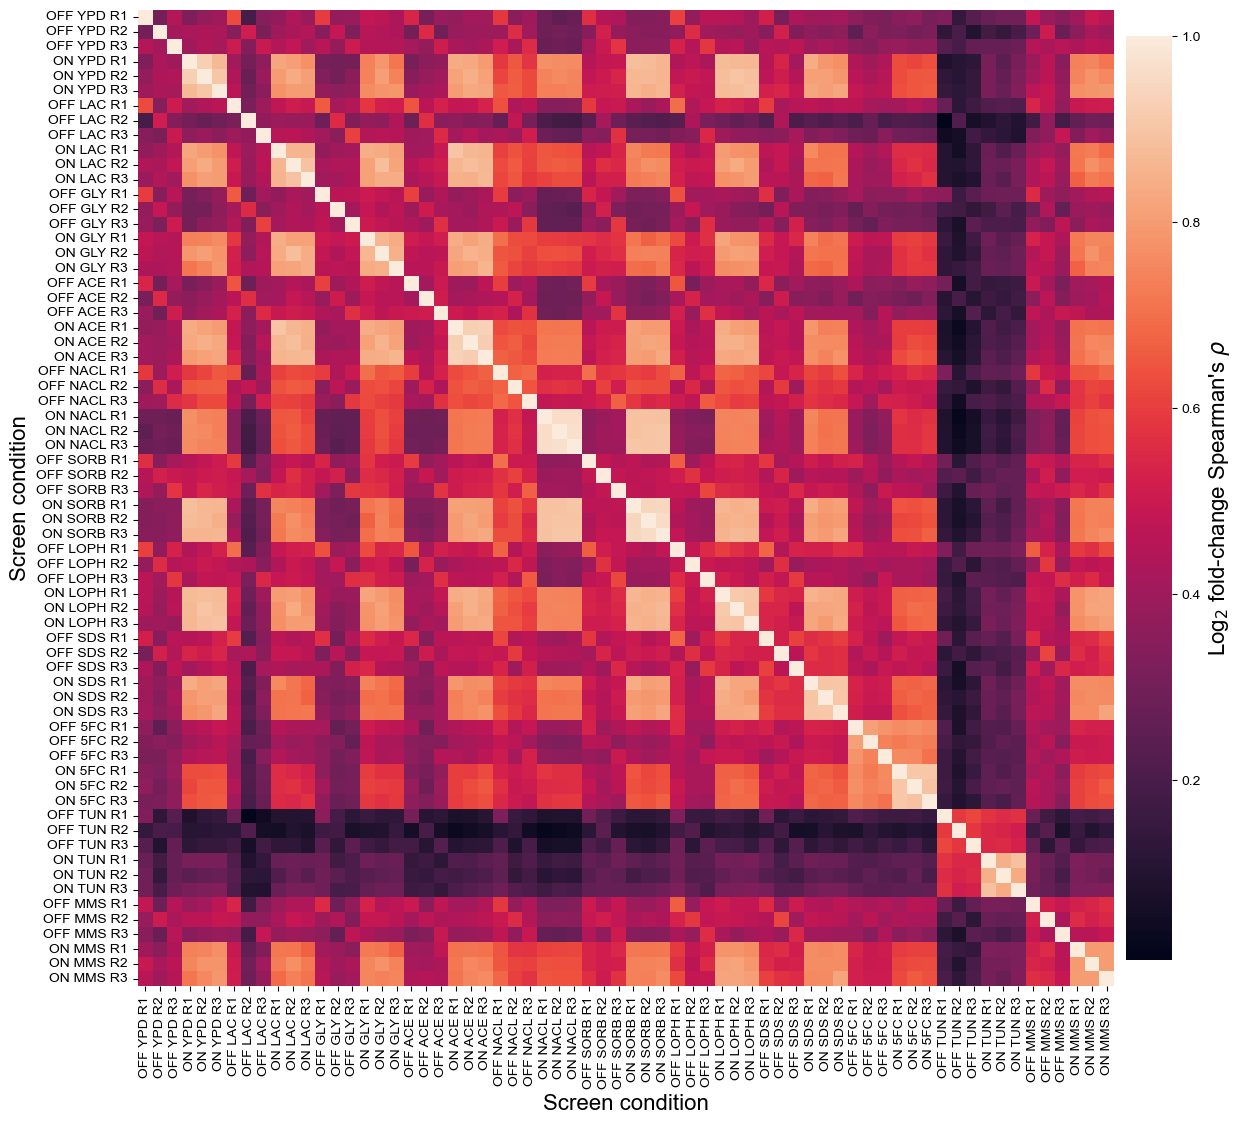

In [27]:
plt.figure(figsize=(15,15))

ax = sns.heatmap(sgRNA_df[log2_col_list_mod].corr(method='spearman'), yticklabels=log2_col_names, xticklabels=log2_col_names, 
            square=True, cbar_kws={'label':r"Log$_{2}$ fold-change Spearman's $\rho$", 'shrink':0.8, 'pad':0.01})

ax.figure.axes[-1].yaxis.label.set_size(16)


plt.xlabel('Screen condition', fontsize=16)
plt.ylabel('Screen condition', fontsize=16)

plt.savefig('./figures/spearman_corr_all_by_all.svg', dpi=300, format='svg')


In [28]:
for cond in ['YPD', 'LAC', 'GLY', 'ACE', 'NACL', 'SORB', 'LOPH', 'SDS', '5FC', 'TUN', 'MMS']:

    cols_names = ['log2fc_NoATC_'+cond+'_T3_1', 'log2fc_NoATC_'+cond+'_T3_2', 'log2fc_NoATC_'+cond+'_T3_3']

    rho12, pval12 = stats.spearmanr(sgRNA_df[cols_names[0]], sgRNA_df[cols_names[1]], nan_policy='omit')
    rho13, pval13 = stats.spearmanr(sgRNA_df[cols_names[0]], sgRNA_df[cols_names[2]], nan_policy='omit')
    rho23, pval23 = stats.spearmanr(sgRNA_df[cols_names[1]], sgRNA_df[cols_names[2]], nan_policy='omit')
    med_rho = np.median([rho12, rho13, rho23])

    print(cond, rho12, rho13, rho23, 'median', med_rho)
    

YPD 0.9249394098945475 0.8712192051452246 0.9010562061067857 median 0.9010562061067857
LAC 0.8586949999347762 0.8538228241493656 0.891873520993215 median 0.8586949999347762
GLY 0.8623368109174405 0.8344230214625282 0.8489468305508466 median 0.8489468305508466
ACE 0.9261567461093935 0.9305026163098864 0.9205528397468054 median 0.9261567461093935
NACL 0.9616638061321661 0.9613514134317601 0.9717675827502933 median 0.9616638061321661
SORB 0.9445455298706098 0.949205234529451 0.9591243137919977 median 0.949205234529451
LOPH 0.9138829991950913 0.8999645600106712 0.8957074594517953 median 0.8999645600106712
SDS 0.8980535063922584 0.9003378184854929 0.9039783502773288 median 0.9003378184854929
5FC 0.9060773269599008 0.906405498577627 0.891390897575892 median 0.9060773269599008
TUN 0.8482996986794813 0.8899070217734342 0.8336579237073755 median 0.8482996986794813
MMS 0.7950047053231267 0.8001657763569828 0.8012603221970136 median 0.8001657763569828


In [30]:
is_control = sgRNA_df['control'] == 1
is_test = sgRNA_df['control'] == 0

In [31]:
noATC_FC_col_list = []

for condition in condition_list:
    
    median_NoATC_col_name = 'median_log2fc_NoATC_'+condition
    noATC_FC_col_list.append(median_NoATC_col_name)
    
noATC_FC_col_list

['median_log2fc_NoATC_YPD',
 'median_log2fc_NoATC_LAC',
 'median_log2fc_NoATC_GLY',
 'median_log2fc_NoATC_ACE',
 'median_log2fc_NoATC_NACL',
 'median_log2fc_NoATC_SORB',
 'median_log2fc_NoATC_LOPH',
 'median_log2fc_NoATC_SDS',
 'median_log2fc_NoATC_5FC',
 'median_log2fc_NoATC_TUN',
 'median_log2fc_NoATC_MMS']

-1.4029148345962223 0.011213479018316885 108 0.22832980972515857 0.0491108849598508


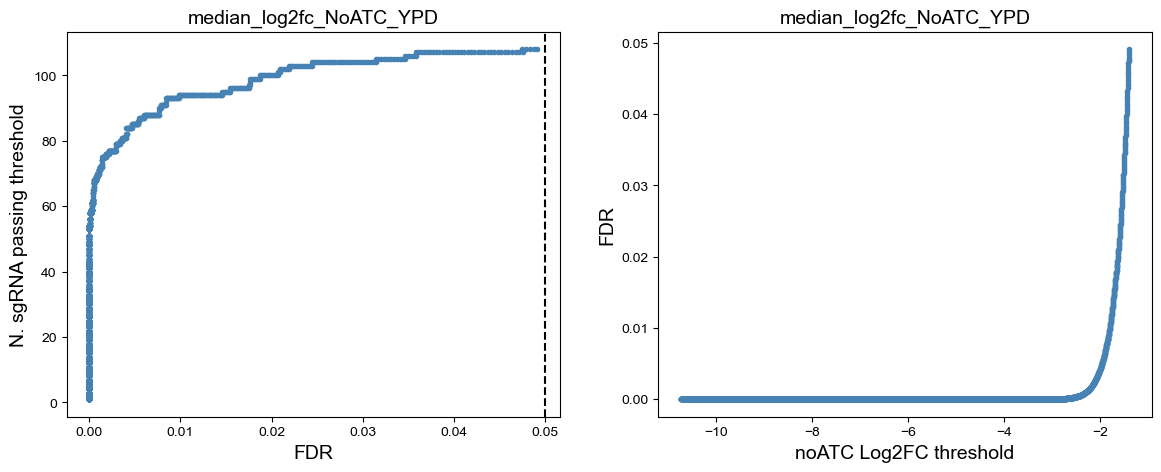

-0.9842570558628232 0.009900418541179744 95 0.20084566596194503 0.049293662841873885


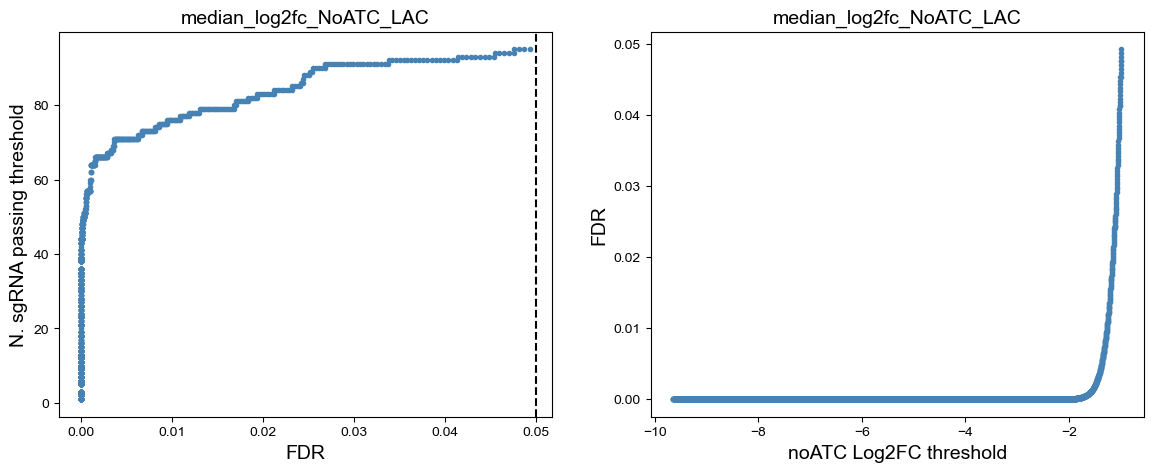

-0.9078560591681946 0.009844500533792077 95 0.20084566596194503 0.04901525002614371


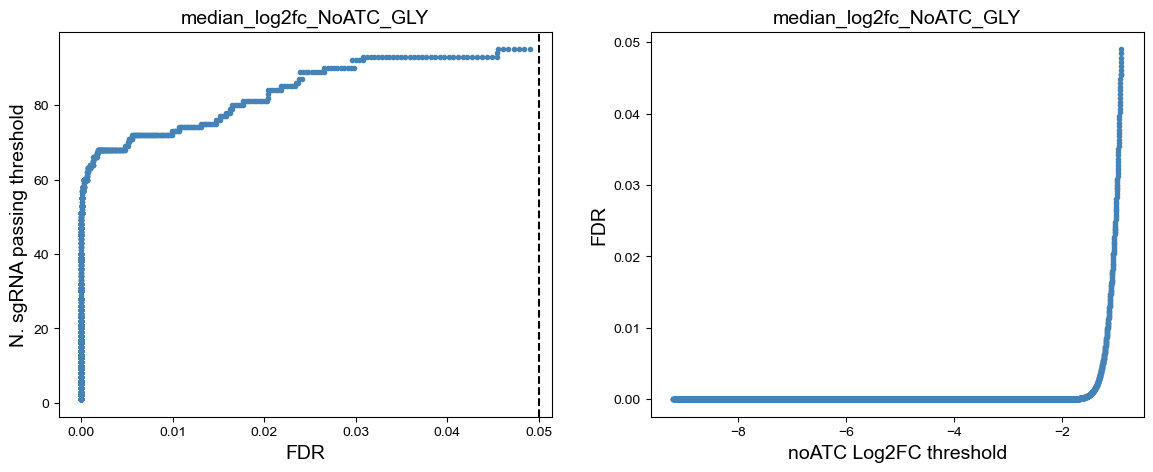

-1.2698725797435646 0.010594985074363438 102 0.2156448202959831 0.0491316464722932


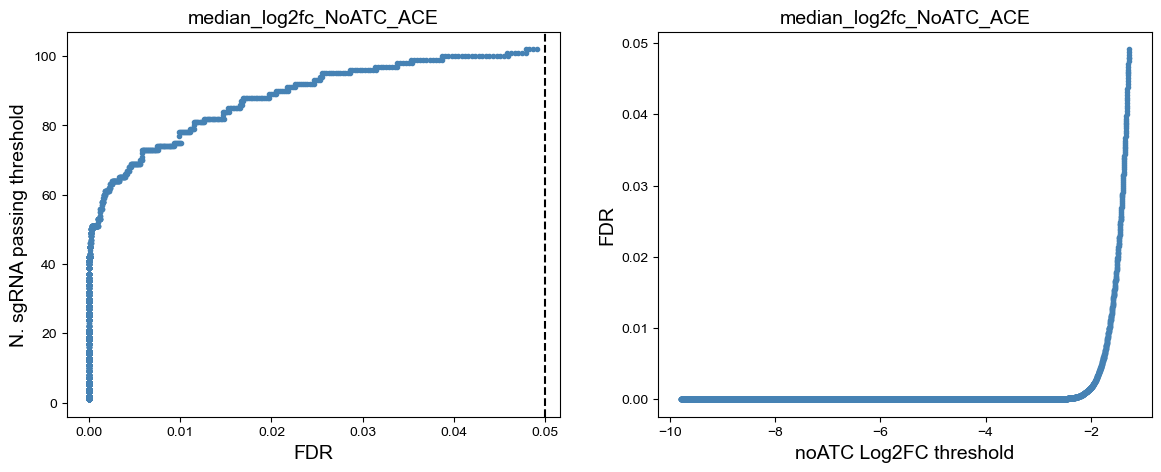

-5.47207838129719 0.005490774541300826 53 0.11205073995771671 0.04900257279311869


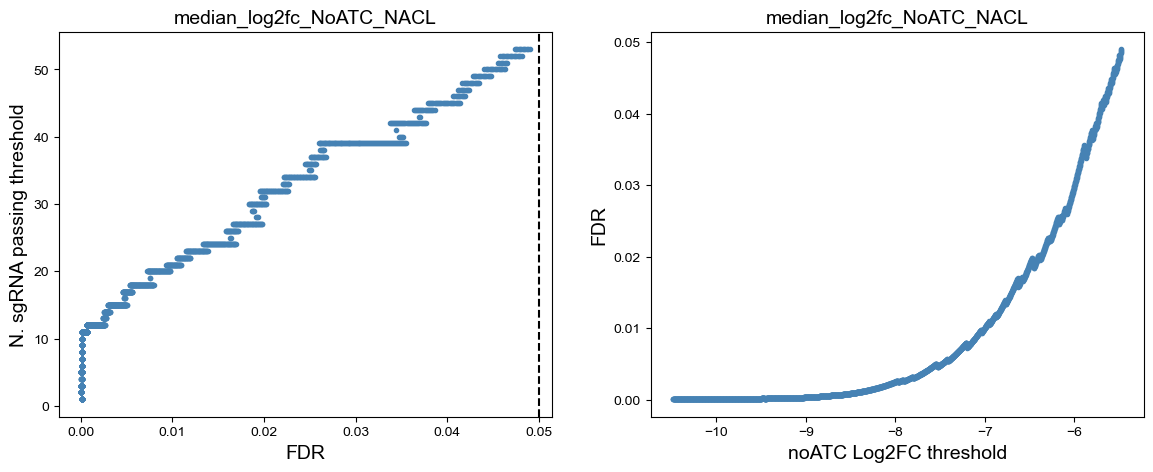

-4.07254708531998 0.00529952253746567 51 0.10782241014799154 0.04915047372982867


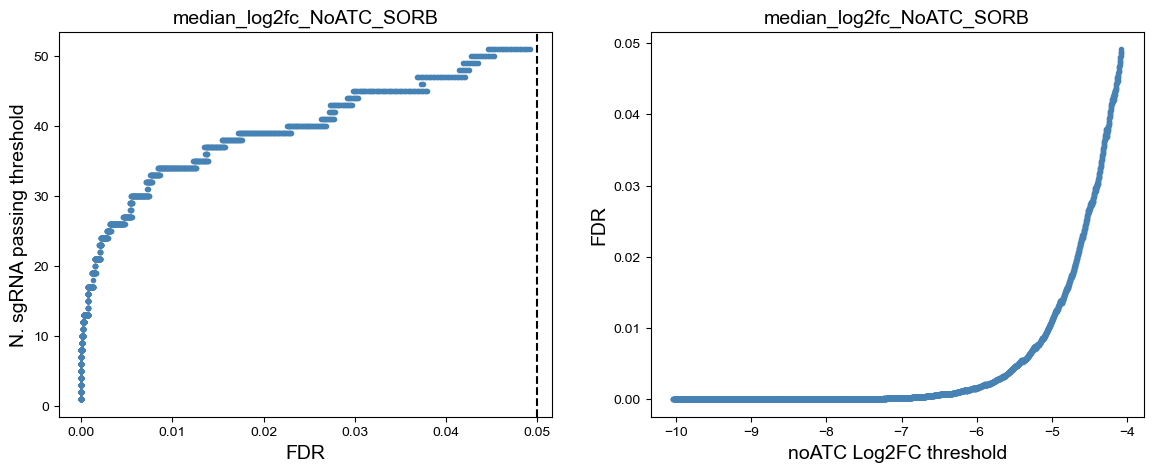

-1.6791209710527575 0.009686377411962465 93 0.19661733615221988 0.04926512382643275


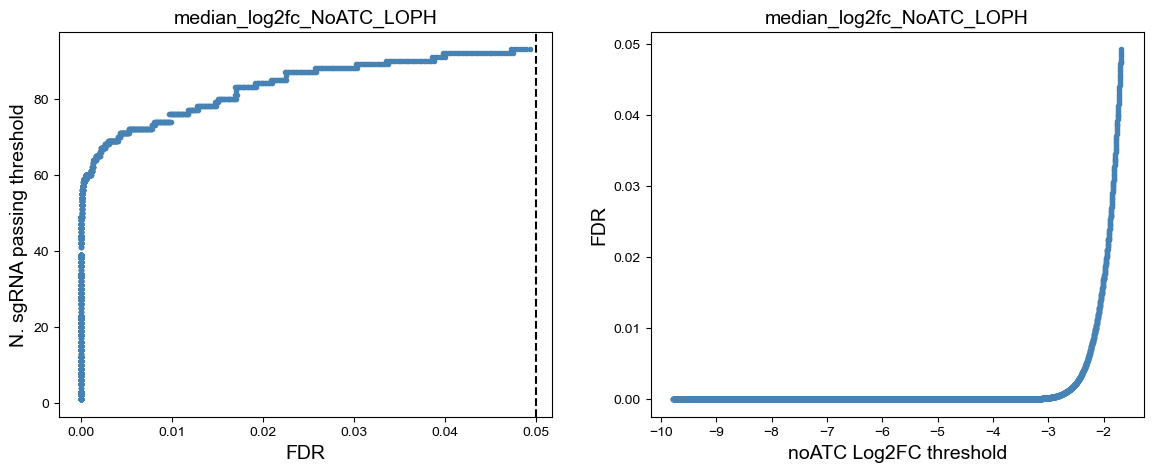

-1.6807095729349957 0.01038360097701938 100 0.21141649048625794 0.04911443262130167


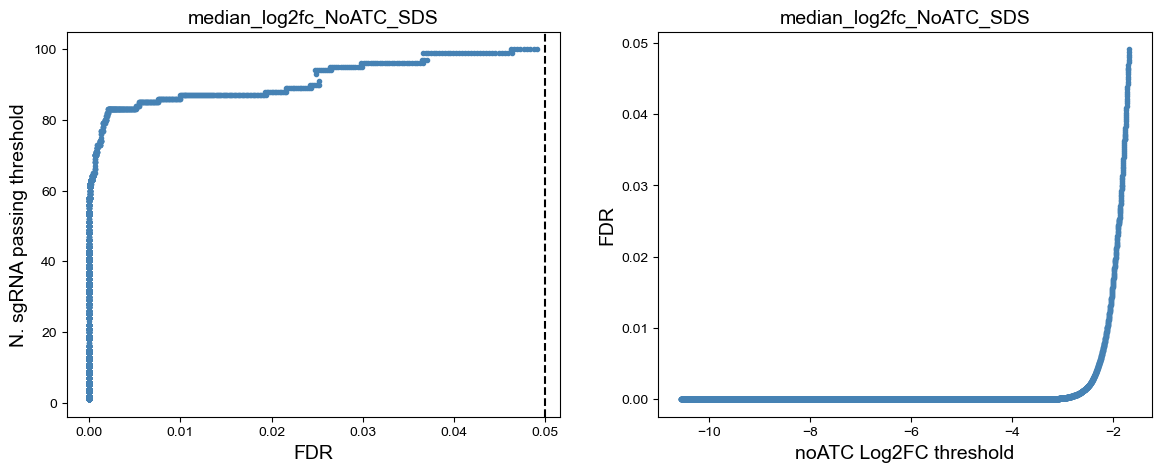

-2.226640214532156 0.006666085130291188 64 0.13530655391120508 0.049266535416058306


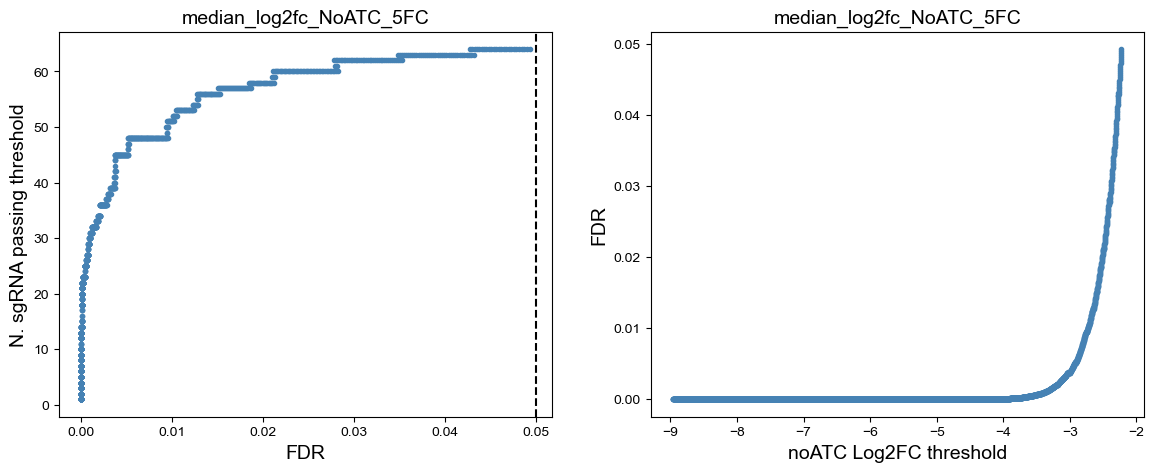

-1.9314562476036237 0.0034268478218364004 33 0.06976744186046512 0.04911815211298841


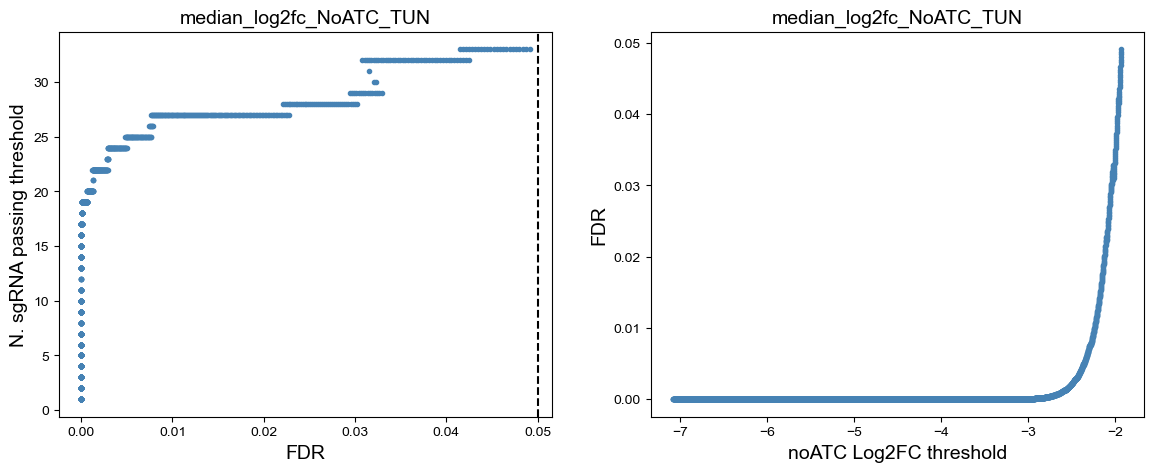

-1.1400543473287854 0.008263117943848776 79 0.16701902748414377 0.04947411123342368


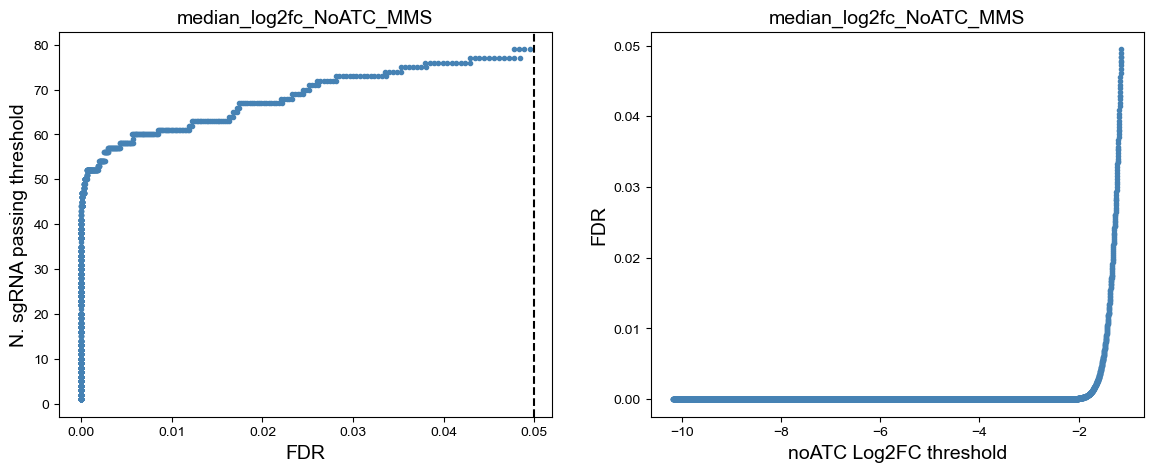

In [32]:
stats_dict_noATC_fc={}



for col in noATC_FC_col_list:
    
    bins = np.linspace(min(sgRNA_df[col].dropna())+0.01, 0, 5000)
    #                                                        5000
    
    noATC_mean, noATC_scale = stats.norm.fit(sgRNA_df[is_control][col].dropna())


    plt.figure(figsize=(14,5))

    ax1 = plt.subplot(121)
    ax2 = plt.subplot(122)
    
    stats_dict={}


    for val in bins:

        FPR = stats.norm.cdf(val, loc=noATC_mean, scale=noATC_scale)

        positives = len([x for x in sgRNA_df[is_test][col] if x < val])
        PR = positives/len(sgRNA_df[is_test][col].dropna())

        FDR = FPR/PR

        #print(val, FPR, positives, PR, FDR)

        ax1.plot(FDR, positives, marker='o', color='steelblue', ms= 3)
        ax2.plot(val, FDR, marker='o', color='steelblue', ms= 3)


        if FDR >= 0.049:
            #    0.25
            print(val, FPR, positives, PR, FDR)
            stats_dict['threshold'] = val
            stats_dict['positives'] = positives

            
            break
        stats_dict_noATC_fc[col] = stats_dict

    ax1.axvline(0.05, color='k', linestyle='--')
    ax1.set_xlabel('FDR', fontsize=14)
    ax1.set_ylabel('N. sgRNA passing threshold', fontsize=14)
    ax1.set_title(col, fontsize=14)


    ax2.set_xlabel('noATC Log2FC threshold', fontsize=14)
    ax2.set_ylabel('FDR', fontsize=14)
    ax2.set_title(col, fontsize=14)
    plt.show()

In [34]:
stats_dict_noATC_fc

{'median_log2fc_NoATC_YPD': {'threshold': -1.4029148345962223,
  'positives': 108},
 'median_log2fc_NoATC_LAC': {'threshold': -0.9842570558628232,
  'positives': 95},
 'median_log2fc_NoATC_GLY': {'threshold': -0.9078560591681946,
  'positives': 95},
 'median_log2fc_NoATC_ACE': {'threshold': -1.2698725797435646,
  'positives': 102},
 'median_log2fc_NoATC_NACL': {'threshold': -5.47207838129719, 'positives': 53},
 'median_log2fc_NoATC_SORB': {'threshold': -4.07254708531998, 'positives': 51},
 'median_log2fc_NoATC_LOPH': {'threshold': -1.6791209710527575,
  'positives': 93},
 'median_log2fc_NoATC_SDS': {'threshold': -1.6807095729349957,
  'positives': 100},
 'median_log2fc_NoATC_5FC': {'threshold': -2.226640214532156, 'positives': 64},
 'median_log2fc_NoATC_TUN': {'threshold': -1.9314562476036237,
  'positives': 33},
 'median_log2fc_NoATC_MMS': {'threshold': -1.1400543473287854,
  'positives': 79}}

In [35]:
noATC_stats_df = pd.DataFrame.from_dict(stats_dict_noATC_fc, orient='index')
noATC_stats_df

,threshold,positives
median_log2fc_NoATC_YPD,-1.402915,108
median_log2fc_NoATC_LAC,-0.984257,95
median_log2fc_NoATC_GLY,-0.907856,95
median_log2fc_NoATC_ACE,-1.269873,102
median_log2fc_NoATC_NACL,-5.472078,53
median_log2fc_NoATC_SORB,-4.072547,51
median_log2fc_NoATC_LOPH,-1.679121,93
median_log2fc_NoATC_SDS,-1.680710,100
median_log2fc_NoATC_5FC,-2.226640,64
median_log2fc_NoATC_TUN,-1.931456,33


In [36]:
col_order = ['median_log2fc_NoATC_YPD',
             'median_log2fc_NoATC_LAC', 'median_log2fc_NoATC_GLY', 'median_log2fc_NoATC_ACE',
             'median_log2fc_NoATC_5FC', 'median_log2fc_NoATC_MMS',
             'median_log2fc_NoATC_SDS', 'median_log2fc_NoATC_TUN', 'median_log2fc_NoATC_LOPH',
             'median_log2fc_NoATC_NACL', 'median_log2fc_NoATC_SORB']

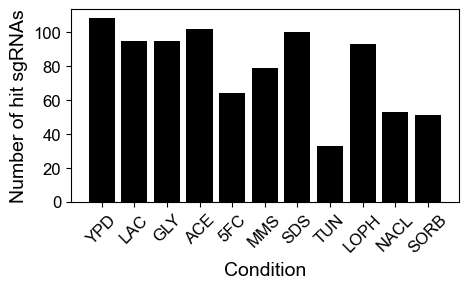

In [37]:
plt.figure(figsize=(5,2.5))

col_names = ['YPD', 
             'LAC', 'GLY', 'ACE',
             '5FC', 'MMS',
             'SDS', 'TUN', 'LOPH',
             'NACL', 'SORB']

plt.bar(x=[x for x in range(0,11)], height = [stats_dict_noATC_fc[y]['positives'] for y in col_order], color=['k','k','k','k','k','k','k','k','k','k','k'])

plt.xticks([x for x in range(0,11)], col_names, fontsize=12, rotation=45)
plt.yticks(fontsize=12)

plt.xlabel('Condition', fontsize=14)
plt.ylabel('Number of hit sgRNAs', fontsize=14)

plt.savefig('./figures/n_hit_per_cdn.svg', format='svg', dpi=300)

In [38]:
gene_hit_counts_dict = {}

for condition in range(0,11):
    no_ATC_index = list(noATC_stats_df.index)[condition]
    threshold_no_ATC = noATC_stats_df.at[no_ATC_index, 'threshold']
    
    gene_list = (sgRNA_df[is_test&(sgRNA_df[no_ATC_index]<threshold_no_ATC)]['alias'].value_counts()/len(sgRNA_df[is_test&(sgRNA_df[no_ATC_index]<threshold_no_ATC)])).to_dict()
    
    gene_hit_counts_dict[no_ATC_index] = gene_list
    
    print(no_ATC_index, threshold_no_ATC, len(sgRNA_df[is_test&(sgRNA_df[no_ATC_index]<threshold_no_ATC)]))

median_log2fc_NoATC_YPD -1.4029148345962223 108
median_log2fc_NoATC_LAC -0.9842570558628232 95
median_log2fc_NoATC_GLY -0.9078560591681946 95
median_log2fc_NoATC_ACE -1.2698725797435646 102
median_log2fc_NoATC_NACL -5.47207838129719 53
median_log2fc_NoATC_SORB -4.07254708531998 51
median_log2fc_NoATC_LOPH -1.6791209710527575 93
median_log2fc_NoATC_SDS -1.6807095729349957 100
median_log2fc_NoATC_5FC -2.226640214532156 64
median_log2fc_NoATC_TUN -1.9314562476036237 33
median_log2fc_NoATC_MMS -1.1400543473287854 79


In [39]:
hit_df = pd.DataFrame(gene_hit_counts_dict).fillna(0)
hit_df

,median_log2fc_NoATC_YPD,median_log2fc_NoATC_LAC,median_log2fc_NoATC_GLY,median_log2fc_NoATC_ACE,median_log2fc_NoATC_NACL,median_log2fc_NoATC_SORB,median_log2fc_NoATC_LOPH,median_log2fc_NoATC_SDS,median_log2fc_NoATC_5FC,median_log2fc_NoATC_TUN,median_log2fc_NoATC_MMS
FBA1,0.037037,0.000000,0.000000,0.000000,0.018868,0.039216,0.043011,0.04,0.031250,0.090909,0.050633
CR_04140W,0.037037,0.042105,0.042105,0.039216,0.000000,0.019608,0.032258,0.03,0.015625,0.030303,0.025316
CR_01370C,0.037037,0.042105,0.042105,0.039216,0.000000,0.019608,0.021505,0.03,0.031250,0.000000,0.012658
HSP90,0.027778,0.010526,0.010526,0.000000,0.000000,0.019608,0.032258,0.01,0.000000,0.000000,0.025316
RRP15,0.027778,0.021053,0.021053,0.029412,0.018868,0.039216,0.032258,0.03,0.046875,0.000000,0.037975
...,...,...,...,...,...,...,...,...,...,...,...
ALR1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.01,0.000000,0.000000,0.000000
FAS2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.01,0.000000,0.000000,0.000000
SVF1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.015625,0.030303,0.000000
HOM6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.030303,0.012658


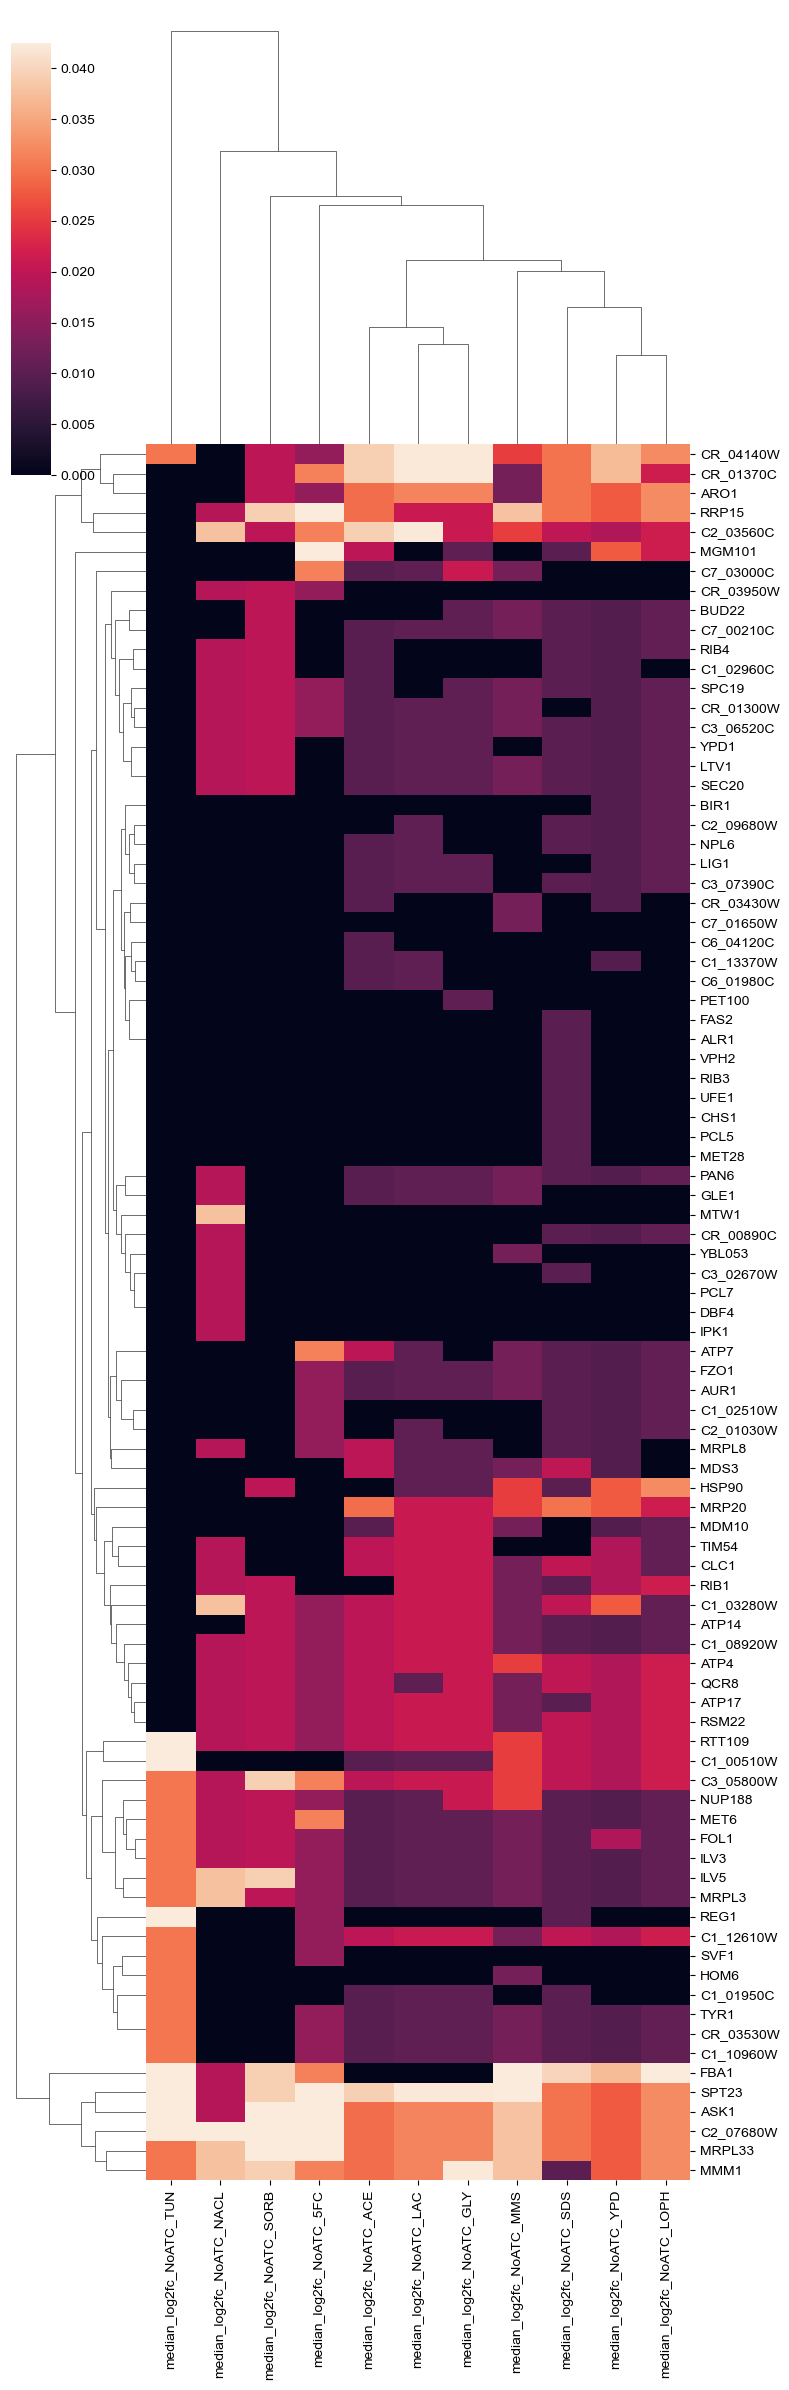

In [40]:

sns.clustermap(hit_df, yticklabels=True, robust=True,figsize=(8,24))

In [41]:
def MAD(x):
    med = np.median(x)
    x   = abs(x-med)
    MAD = np.median(x)
    return MAD

In [42]:
for condition in condition_list:
    for induction in ['ATC', 'NoATC']:
        std_col_name = 'std_log2fc_'+induction+'_'+condition
        mad_col_name = 'mad_log2fc_'+induction+'_'+condition
        col_start='log2fc_'+induction+'_'+condition
        
        
        sgRNA_df[std_col_name] = sgRNA_df[[(col_start+'_T3_1'),(col_start+'_T3_2'),(col_start+'_T3_3')]].std(axis=1)
        sgRNA_df[mad_col_name] = sgRNA_df[[(col_start+'_T3_1'),(col_start+'_T3_2'),(col_start+'_T3_3')]].apply(MAD, axis=1)

In [43]:
noATC_FC_col_list

['median_log2fc_NoATC_YPD',
 'median_log2fc_NoATC_LAC',
 'median_log2fc_NoATC_GLY',
 'median_log2fc_NoATC_ACE',
 'median_log2fc_NoATC_NACL',
 'median_log2fc_NoATC_SORB',
 'median_log2fc_NoATC_LOPH',
 'median_log2fc_NoATC_SDS',
 'median_log2fc_NoATC_5FC',
 'median_log2fc_NoATC_TUN',
 'median_log2fc_NoATC_MMS']

0
0
1
1
2
2
3
3
4
4
5
5
6


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


6
7


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


7
8


...

/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 31.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:339

9
10


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 34.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 41.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:339

10


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:339

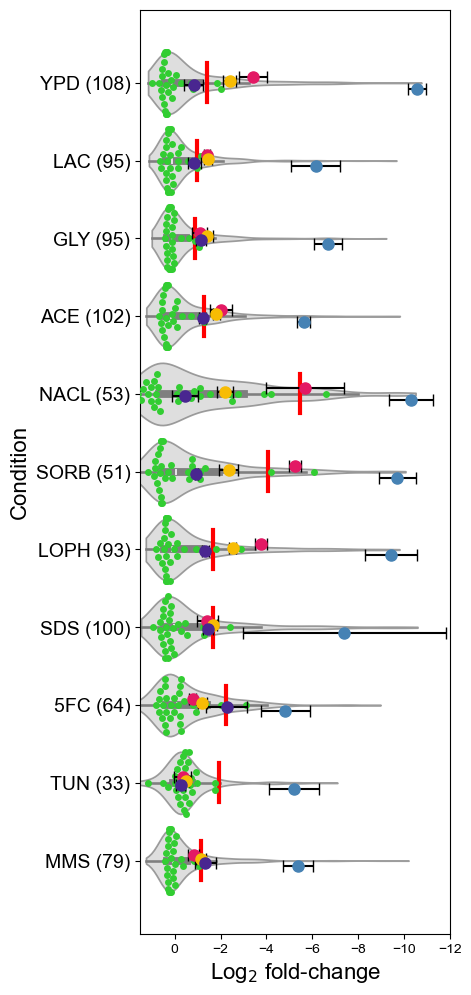

In [44]:
plt.figure(figsize=(4,12))

test_guide_list = [262,263,264,265]

y_loc = 0

for condition in noATC_FC_col_list:
    
    std_col = condition.replace('median', 'std')
    
    print(y_loc)
    sns.swarmplot(x=sgRNA_df[is_control][condition], y = y_loc, zorder=8, color='limegreen', orient='h')
    sns.violinplot(x=sgRNA_df[is_test][condition], y = y_loc, orient='h', color='lightgrey', cut=0, alpha=0.75)
    print(y_loc)
    plt.plot([noATC_stats_df.at[condition, 'threshold'],noATC_stats_df.at[condition, 'threshold'] ], [(y_loc-0.25), (y_loc+0.25)], 'r-', lw=3)
    
    plt.errorbar(sgRNA_df.at[test_guide_list[0], condition], y_loc-0.075, 
             xerr=sgRNA_df.at[test_guide_list[0], std_col]*2, 
             color='#e31964', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[1],condition], y_loc-0.025, 
             xerr=sgRNA_df.at[test_guide_list[1],std_col]*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[2],condition], y_loc+0.025, 
             xerr=sgRNA_df.at[test_guide_list[2],std_col]*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[3],condition], y_loc+0.075, 
             xerr=sgRNA_df.at[test_guide_list[3],std_col]*2, 
             color='steelblue', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

    
    y_loc+=1

    
plt.yticks(range(0,11), ['YPD (108)', 'LAC (95)', 'GLY (95)', 'ACE (102)', 'NACL (53)', 'SORB (51)', 'LOPH (93)', 
                         'SDS (100)', '5FC (64)', 'TUN (33)', 'MMS (79)'], fontsize=14)
plt.ylabel('Condition', fontsize=16)

plt.xlabel('Log$_{2}$ fold-change', fontsize=16)

#plt.legend([str(x) for x in test_guide_list], loc='upper right', bbox_to_anchor=(1.25, 0.5))

plt.xlim(1.5,-12)
plt.savefig('./figures/MMM1_violinplot.svg', format='svg', dpi=300)

## FBA1 

0
0
1
1
2
2
3
3
4
4
5
5
6


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


6
7


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


7
8
8
9


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399

9
10


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 31.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399

10


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399

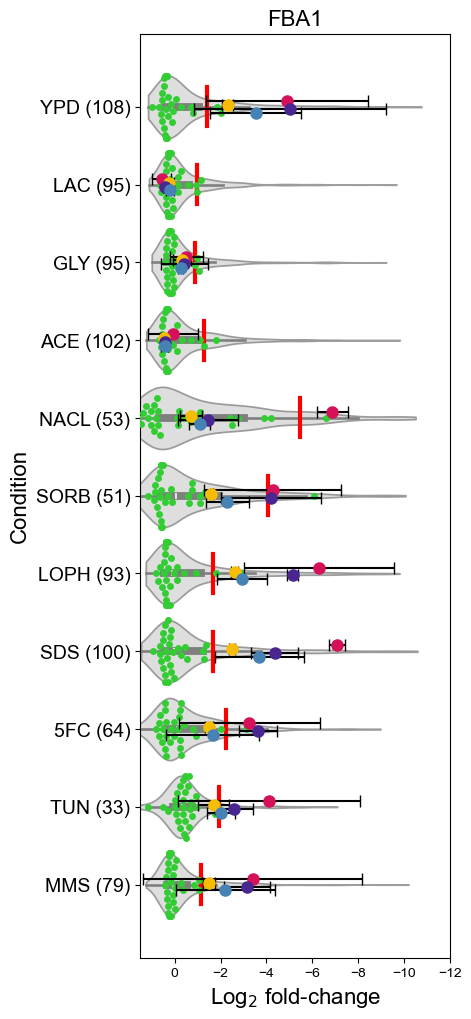

In [45]:
plt.figure(figsize=(4,12))

test_guide_list = [274,275,276,277]

y_loc = 0

for condition in noATC_FC_col_list:
    
    std_col = condition.replace('median', 'std')
    
    print(y_loc)
    sns.swarmplot(x=sgRNA_df[is_control][condition], y = y_loc, zorder=8, color='limegreen', orient='h')
    sns.violinplot(x=sgRNA_df[is_test][condition], y = y_loc, orient='h', color='lightgrey', cut=0, alpha=0.75)
    print(y_loc)
    plt.plot([noATC_stats_df.at[condition, 'threshold'],noATC_stats_df.at[condition, 'threshold'] ], [(y_loc-0.25), (y_loc+0.25)], 'r-', lw=3)
    
    plt.errorbar(sgRNA_df.at[test_guide_list[0], condition], y_loc-0.075, 
             xerr=sgRNA_df.at[test_guide_list[0], std_col]*2, 
             color='#d41159', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[1],condition], y_loc-0.025, 
             xerr=sgRNA_df.at[test_guide_list[1],std_col]*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[2],condition], y_loc+0.025, 
             xerr=sgRNA_df.at[test_guide_list[2],std_col]*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[3],condition], y_loc+0.075, 
             xerr=sgRNA_df.at[test_guide_list[3],std_col]*2, 
             color='steelblue', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

    
    y_loc+=1

    
plt.yticks(range(0,11), ['YPD (108)', 'LAC (95)', 'GLY (95)', 'ACE (102)', 'NACL (53)', 'SORB (51)', 'LOPH (93)', 
                         'SDS (100)', '5FC (64)', 'TUN (33)', 'MMS (79)'], fontsize=14)
plt.ylabel('Condition', fontsize=16)

plt.xlabel('Log$_{2}$ fold-change', fontsize=16)

#plt.legend([str(x) for x in test_guide_list], loc='upper right', bbox_to_anchor=(1.25, 0.5))

plt.title('FBA1', fontsize=16)

plt.xlim(1.5,-12)

plt.savefig('./figures/FBA1_violinplot.svg', format='svg', dpi=300)

In [46]:
noATC_FC_col_list_no_TUN = ['median_log2fc_NoATC_YPD',
                             'median_log2fc_NoATC_LAC',
                             'median_log2fc_NoATC_GLY',
                             'median_log2fc_NoATC_ACE',
                             'median_log2fc_NoATC_NACL',
                             'median_log2fc_NoATC_SORB',
                             'median_log2fc_NoATC_LOPH',
                             'median_log2fc_NoATC_SDS',
                             'median_log2fc_NoATC_5FC',
                            'median_log2fc_NoATC_MMS']

In [47]:
sgRNA_df[sgRNA_df['alias']=='MMM1']

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,std_log2fc_NoATC_5FC,mad_log2fc_NoATC_5FC,std_log2fc_ATC_TUN,mad_log2fc_ATC_TUN,std_log2fc_NoATC_TUN,mad_log2fc_NoATC_TUN,std_log2fc_ATC_MMS,mad_log2fc_ATC_MMS,std_log2fc_NoATC_MMS,mad_log2fc_NoATC_MMS
262,C4_00560C,MMM1,265,TAGTGCCAGAGATTTCACAG,0,+,89.0,no,-54.0,54.0,...,0.078961,0.045436,0.169519,0.123083,0.179530,0.008174,0.103622,0.063379,0.122539,0.045660
263,C4_00560C,MMM1,266,AGTGCCAGAGATTTCACAGT,0,+,88.0,no,-53.0,53.0,...,0.100023,0.069512,0.061118,0.027380,0.070289,0.018241,0.091406,0.041328,0.100557,0.037536
264,C4_00560C,MMM1,267,TGCCAGAGATTTCACAGTGG,0,+,86.0,no,-51.0,51.0,...,0.441822,0.204524,0.225228,0.024802,0.099919,0.071464,0.275234,0.112287,0.224378,0.193559
265,C4_00560C,MMM1,268,CCAGAGATTTCACAGTGGGG,0,+,84.0,no,-49.0,49.0,...,0.532134,0.212922,0.056178,0.037047,0.544231,0.218797,0.326870,0.286803,0.322377,0.158868


0
0
1
1
2
2
3
3
4
4
5
5
6


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


6
7


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


7
8


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:339

8
9


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 31.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


9


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:339

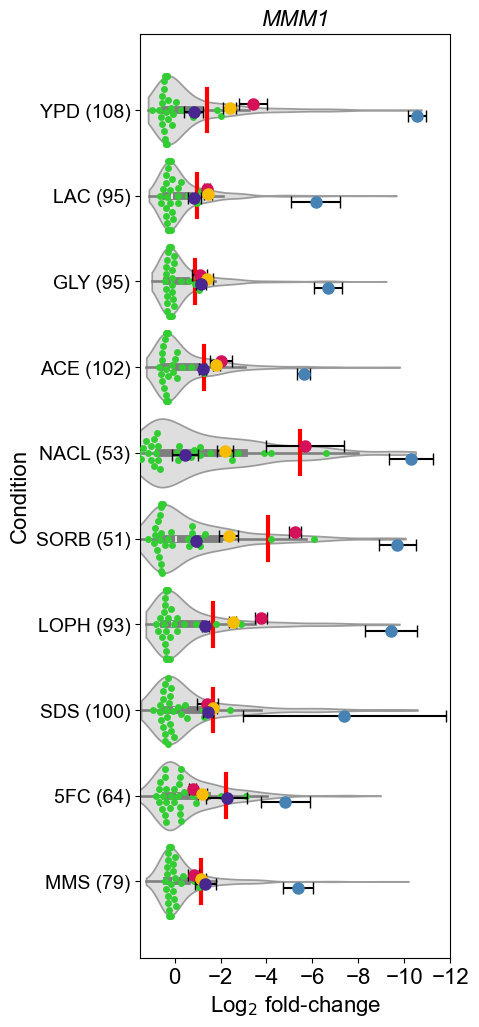

In [48]:
plt.figure(figsize=(4,12))

test_guide_list = [262,263,264,265]

y_loc = 0

for condition in noATC_FC_col_list_no_TUN:
    
    std_col = condition.replace('median', 'std')
    
    print(y_loc)
    sns.swarmplot(x=sgRNA_df[is_control][condition], y = y_loc, zorder=8, color='limegreen', orient='h')
    sns.violinplot(x=sgRNA_df[is_test][condition], y = y_loc, orient='h', color='lightgrey', cut=0, alpha=0.75)
    print(y_loc)
    plt.plot([noATC_stats_df.at[condition, 'threshold'],noATC_stats_df.at[condition, 'threshold'] ], [(y_loc-0.25), (y_loc+0.25)], 'r-', lw=3)
    
    plt.errorbar(sgRNA_df.at[test_guide_list[0], condition], y_loc-0.075, 
             xerr=sgRNA_df.at[test_guide_list[0], std_col]*2, 
             color='#d41159', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[1],condition], y_loc-0.025, 
             xerr=sgRNA_df.at[test_guide_list[1],std_col]*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[2],condition], y_loc+0.025, 
             xerr=sgRNA_df.at[test_guide_list[2],std_col]*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[3],condition], y_loc+0.075, 
             xerr=sgRNA_df.at[test_guide_list[3],std_col]*2, 
             color='steelblue', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

    
    y_loc+=1

    
plt.yticks(range(0,10), ['YPD (108)', 'LAC (95)', 'GLY (95)', 'ACE (102)', 'NACL (53)', 'SORB (51)', 'LOPH (93)', 
                         'SDS (100)', '5FC (64)', 'MMS (79)'], fontsize=14)
plt.ylabel('Condition', fontsize=16)

plt.xlabel('Log$_{2}$ fold-change', fontsize=16)

plt.title('MMM1', fontsize=16, style='italic')

#plt.legend([str(x) for x in test_guide_list], loc='upper right', bbox_to_anchor=(1.25, 0.5))

plt.xlim(1.5,-12)
plt.xticks(fontsize=16)


plt.savefig('./figures/violinplots_MMM1.svg', format='svg', dpi=300)

In [49]:
sgRNA_df[sgRNA_df['alias']=='SPT23']

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,std_log2fc_NoATC_5FC,mad_log2fc_NoATC_5FC,std_log2fc_ATC_TUN,mad_log2fc_ATC_TUN,std_log2fc_NoATC_TUN,mad_log2fc_NoATC_TUN,std_log2fc_ATC_MMS,mad_log2fc_ATC_MMS,std_log2fc_NoATC_MMS,mad_log2fc_NoATC_MMS
214,C2_10280C,SPT23,217,AAAGTGGAAAGTGGTGGAGG,0,-,150.0,no,11.0,11.0,...,1.253914,0.636298,0.245854,0.226185,0.411004,0.073589,0.275734,0.226778,0.403203,0.090738
215,C2_10280C,SPT23,218,TGTGTGTAATAAGTGTGTGT,0,-,281.0,no,-120.0,120.0,...,0.341628,0.319437,0.109475,0.102190,0.134554,0.011601,0.146570,0.081615,0.133433,0.075206
216,C2_10280C,SPT23,219,TTGAGTAGGCGGGTGGTAGT,0,-,246.0,no,-85.0,85.0,...,2.552566,2.397651,0.166668,0.072789,1.694936,0.975661,0.785917,0.522871,1.408205,0.826945
217,C2_10280C,SPT23,220,TTTGAGTAGGCGGGTGGTAG,0,-,245.0,no,-84.0,84.0,...,0.373517,0.257180,0.291111,0.048378,0.229924,0.028675,0.391497,0.390036,0.111237,0.032013


0
0
1
1
2
2
3
3
4
4
5


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


5
6
6
7


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


7
8


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 34.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:339

8
9


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 31.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 41.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


9


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:339

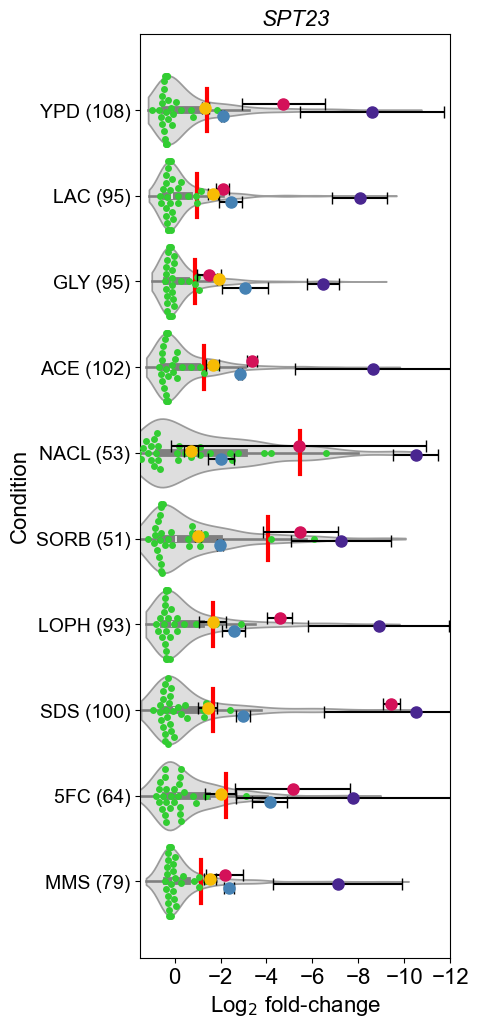

In [50]:
plt.figure(figsize=(4,12))

test_guide_list = [214,215,216,217]

y_loc = 0

for condition in noATC_FC_col_list_no_TUN:
    
    std_col = condition.replace('median', 'std')
    
    print(y_loc)
    sns.swarmplot(x=sgRNA_df[is_control][condition], y = y_loc, zorder=8, color='limegreen', orient='h')
    sns.violinplot(x=sgRNA_df[is_test][condition], y = y_loc, orient='h', color='lightgrey', cut=0, alpha=0.75)
    print(y_loc)
    plt.plot([noATC_stats_df.at[condition, 'threshold'],noATC_stats_df.at[condition, 'threshold'] ], [(y_loc-0.25), (y_loc+0.25)], 'r-', lw=3)
    
    plt.errorbar(sgRNA_df.at[test_guide_list[0], condition], y_loc-0.075, 
             xerr=sgRNA_df.at[test_guide_list[0], std_col]*2, 
             color='#d41159', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[1],condition], y_loc-0.025, 
             xerr=sgRNA_df.at[test_guide_list[1],std_col]*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[2],condition], y_loc+0.025, 
             xerr=sgRNA_df.at[test_guide_list[2],std_col]*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[3],condition], y_loc+0.075, 
             xerr=sgRNA_df.at[test_guide_list[3],std_col]*2, 
             color='steelblue', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

    
    y_loc+=1

    
plt.yticks(range(0,10), ['YPD (108)', 'LAC (95)', 'GLY (95)', 'ACE (102)', 'NACL (53)', 'SORB (51)', 'LOPH (93)', 
                         'SDS (100)', '5FC (64)', 'MMS (79)'], fontsize=14)
plt.ylabel('Condition', fontsize=16)

plt.xlabel('Log$_{2}$ fold-change', fontsize=16)

plt.title('SPT23', fontsize=16, style='italic')

#plt.legend([str(x) for x in test_guide_list], loc='upper right', bbox_to_anchor=(1.25, 0.5))

plt.xlim(1.5,-12)
plt.xticks(fontsize=16)


plt.savefig('./figures/violinplots_SPT23.svg', format='svg', dpi=300)

In [51]:
sgRNA_df[sgRNA_df['alias']=='C2_07680W']

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,std_log2fc_NoATC_5FC,mad_log2fc_NoATC_5FC,std_log2fc_ATC_TUN,mad_log2fc_ATC_TUN,std_log2fc_NoATC_TUN,mad_log2fc_NoATC_TUN,std_log2fc_ATC_MMS,mad_log2fc_ATC_MMS,std_log2fc_NoATC_MMS,mad_log2fc_NoATC_MMS
198,C2_07680W,C2_07680W,201,GTTAACGTCGGTCTTTCTTC,0,-,156.0,no,-135.0,135.0,...,0.049993,0.048491,0.137574,0.024925,0.074914,0.073971,0.336213,0.268778,0.073242,0.012306
199,C2_07680W,C2_07680W,202,TTCTCCCTCTCCATTCTGTT,0,+,84.0,no,-63.0,63.0,...,1.057555,0.487950,0.144987,0.001746,0.198195,0.062332,0.262326,0.058911,0.559346,0.235157
200,C2_07680W,C2_07680W,203,CTAACCAAACAGAATGGAGA,0,-,77.0,no,-56.0,56.0,...,1.576186,0.728541,0.020191,0.005866,0.859542,0.264630,1.076933,0.833889,1.596962,0.085153
201,C2_07680W,C2_07680W,204,TCTAACCAAACAGAATGGAG,0,-,76.0,no,-55.0,55.0,...,1.561131,0.631984,0.068463,0.026334,0.570796,0.542500,0.476432,0.441518,2.882976,0.425171


0
0
1
1
2
2
3
3
4
4
5


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


5
6


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


6
7


...

/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 34.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:339

8
9


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 31.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 41.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


9


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:339

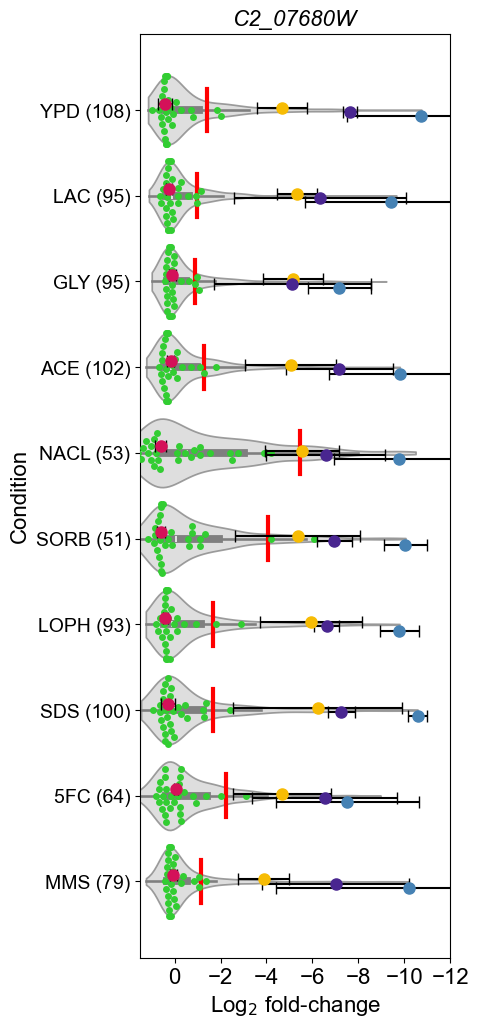

In [52]:
plt.figure(figsize=(4,12))

test_guide_list = [198,199,200,201]

y_loc = 0

for condition in noATC_FC_col_list_no_TUN:
    
    std_col = condition.replace('median', 'std')
    
    print(y_loc)
    sns.swarmplot(x=sgRNA_df[is_control][condition], y = y_loc, zorder=8, color='limegreen', orient='h')
    sns.violinplot(x=sgRNA_df[is_test][condition], y = y_loc, orient='h', color='lightgrey', cut=0, alpha=0.75)
    print(y_loc)
    plt.plot([noATC_stats_df.at[condition, 'threshold'],noATC_stats_df.at[condition, 'threshold'] ], [(y_loc-0.25), (y_loc+0.25)], 'r-', lw=3)
    
    plt.errorbar(sgRNA_df.at[test_guide_list[0], condition], y_loc-0.075, 
             xerr=sgRNA_df.at[test_guide_list[0], std_col]*2, 
             color='#d41159', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[1],condition], y_loc-0.025, 
             xerr=sgRNA_df.at[test_guide_list[1],std_col]*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[2],condition], y_loc+0.025, 
             xerr=sgRNA_df.at[test_guide_list[2],std_col]*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[3],condition], y_loc+0.075, 
             xerr=sgRNA_df.at[test_guide_list[3],std_col]*2, 
             color='steelblue', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

    
    y_loc+=1

    
plt.yticks(range(0,10), ['YPD (108)', 'LAC (95)', 'GLY (95)', 'ACE (102)', 'NACL (53)', 'SORB (51)', 'LOPH (93)', 
                         'SDS (100)', '5FC (64)', 'MMS (79)'], fontsize=14)
plt.ylabel('Condition', fontsize=16)

plt.xlabel('Log$_{2}$ fold-change', fontsize=16)

plt.title('C2_07680W', fontsize=16, style='italic')

#plt.legend([str(x) for x in test_guide_list], loc='upper right', bbox_to_anchor=(1.25, 0.5))

plt.xlim(1.5,-12)
plt.xticks(fontsize=16)

plt.savefig('./figures/violinplots_C2_07680W.svg', format='svg', dpi=300)

In [53]:
sgRNA_df[sgRNA_df['alias']=='MRPL33']

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,std_log2fc_NoATC_5FC,mad_log2fc_NoATC_5FC,std_log2fc_ATC_TUN,mad_log2fc_ATC_TUN,std_log2fc_NoATC_TUN,mad_log2fc_NoATC_TUN,std_log2fc_ATC_MMS,mad_log2fc_ATC_MMS,std_log2fc_NoATC_MMS,mad_log2fc_NoATC_MMS
218,C3_01080W,MRPL33,221,CGAAAGCTCAACGTTAAGGA,0,+,103.0,no,-27.0,27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
219,C3_01080W,MRPL33,222,CAACGTTAAGGAAGGAAGGA,0,+,95.0,no,-19.0,19.0,...,0.943925,0.490732,0.243413,0.179302,0.108310,0.089426,0.046550,0.008859,0.843885,0.368688
220,C3_01080W,MRPL33,223,TCCCGGACAACACCCAAAAC,0,+,247.0,no,-171.0,171.0,...,0.398980,0.361934,0.110285,0.079122,0.316097,0.119845,0.075402,0.042846,0.242125,0.070517
221,C3_01080W,MRPL33,224,GGTTTGCAAAAACACATTTA,0,+,226.0,no,-150.0,150.0,...,0.369082,0.205987,0.072722,0.009500,0.165055,0.135031,0.169231,0.060494,0.297107,0.040330


0
0
1
1
2
2
3
3
4
4
5
5
6


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


6
7


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


7
8


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


8
9


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 31.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


9


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:339

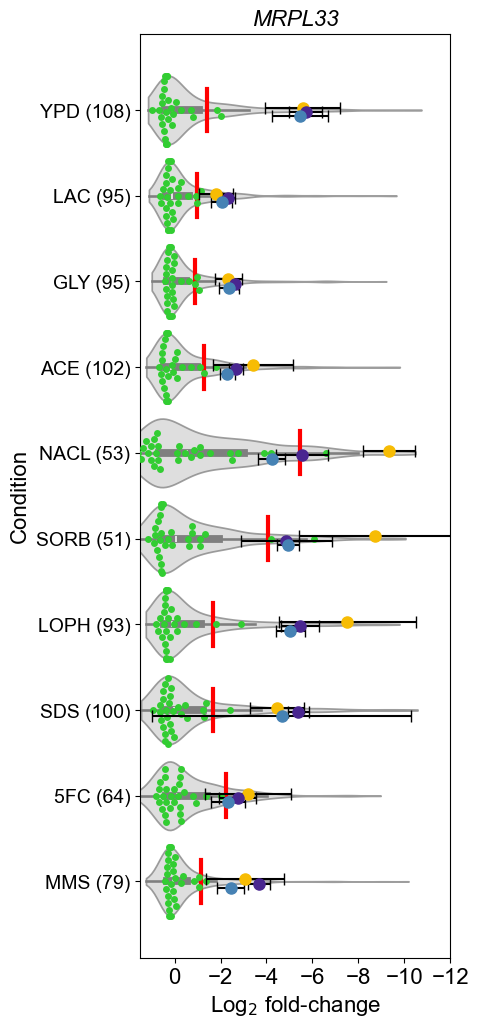

In [54]:
plt.figure(figsize=(4,12))

test_guide_list = [218,219,220,221]

y_loc = 0

for condition in noATC_FC_col_list_no_TUN:
    
    std_col = condition.replace('median', 'std')
    
    print(y_loc)
    sns.swarmplot(x=sgRNA_df[is_control][condition], y = y_loc, zorder=8, color='limegreen', orient='h')
    sns.violinplot(x=sgRNA_df[is_test][condition], y = y_loc, orient='h', color='lightgrey', cut=0, alpha=0.75)
    print(y_loc)
    plt.plot([noATC_stats_df.at[condition, 'threshold'],noATC_stats_df.at[condition, 'threshold'] ], [(y_loc-0.25), (y_loc+0.25)], 'r-', lw=3)
    
    plt.errorbar(sgRNA_df.at[test_guide_list[0], condition], y_loc-0.075, 
             xerr=sgRNA_df.at[test_guide_list[0], std_col]*2, 
             color='#d41159', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[1],condition], y_loc-0.025, 
             xerr=sgRNA_df.at[test_guide_list[1],std_col]*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[2],condition], y_loc+0.025, 
             xerr=sgRNA_df.at[test_guide_list[2],std_col]*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[3],condition], y_loc+0.075, 
             xerr=sgRNA_df.at[test_guide_list[3],std_col]*2, 
             color='steelblue', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

    
    y_loc+=1

    
plt.yticks(range(0,10), ['YPD (108)', 'LAC (95)', 'GLY (95)', 'ACE (102)', 'NACL (53)', 'SORB (51)', 'LOPH (93)', 
                         'SDS (100)', '5FC (64)', 'MMS (79)'], fontsize=14)
plt.ylabel('Condition', fontsize=16)

plt.xlabel('Log$_{2}$ fold-change', fontsize=16)

plt.title('MRPL33', fontsize=16, style='italic')

#plt.legend([str(x) for x in test_guide_list], loc='upper right', bbox_to_anchor=(1.25, 0.5))

plt.xlim(1.5,-12)
plt.xticks(fontsize=16)

plt.savefig('./figures/violinplots_MRPL33.svg', format='svg', dpi=300)

In [55]:
sgRNA_df[sgRNA_df['alias']=='C2_03560C']

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,std_log2fc_NoATC_5FC,mad_log2fc_NoATC_5FC,std_log2fc_ATC_TUN,mad_log2fc_ATC_TUN,std_log2fc_NoATC_TUN,mad_log2fc_NoATC_TUN,std_log2fc_ATC_MMS,mad_log2fc_ATC_MMS,std_log2fc_NoATC_MMS,mad_log2fc_NoATC_MMS
164,C2_03560C,C2_03560C,165,TGGCGCAAAGGACAAAAAAA,0,+,125.0,no,-99.0,99.0,...,0.053173,0.037615,0.052914,0.004256,0.018745,0.009426,0.042379,0.032146,0.025620,0.020502
165,C2_03560C,C2_03560C,166,AGGAAATTCGCCAGAACTCT,0,+,105.0,no,-79.0,79.0,...,0.618880,0.419575,0.263836,0.135711,0.211492,0.063003,0.242381,0.008784,0.151927,0.009540
166,C2_03560C,C2_03560C,167,GGCACTATCACCAAGAGTTC,0,-,92.0,no,-66.0,66.0,...,0.925236,0.885308,0.088407,0.032627,0.119066,0.114526,0.249642,0.097206,0.335772,0.302164
167,C2_03560C,C2_03560C,168,CAAGAATAATGCTTGATTTC,0,-,37.0,no,-11.0,11.0,...,1.107567,0.987085,0.357399,0.202219,0.067043,0.035177,0.569884,0.436734,0.501606,0.117647


0
0
1
1
2
2
3
3
4
4
5
5
6


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


6
7


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


7
8


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


8
9


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


9


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:339

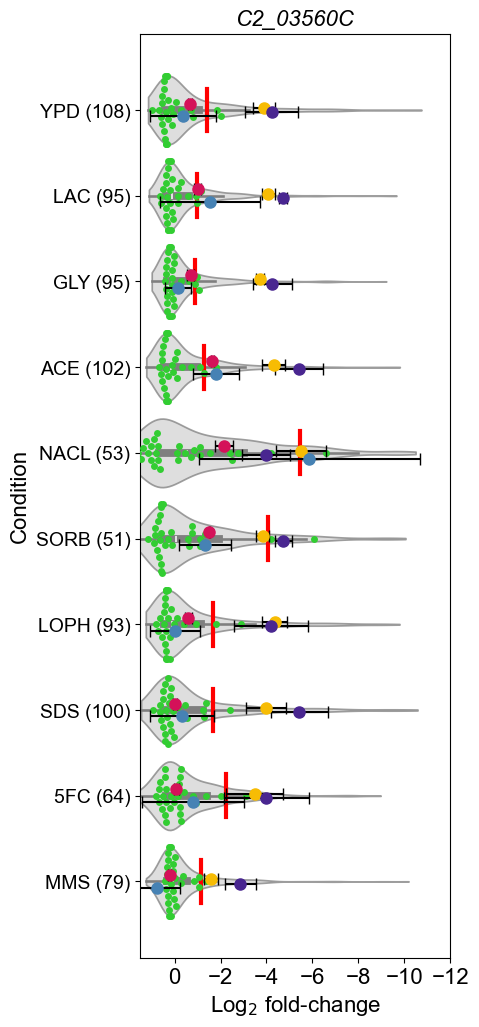

In [56]:
plt.figure(figsize=(4,12))

test_guide_list = [164,165,166,167]

y_loc = 0

for condition in noATC_FC_col_list_no_TUN:
    
    std_col = condition.replace('median', 'std')
    
    print(y_loc)
    sns.swarmplot(x=sgRNA_df[is_control][condition], y = y_loc, zorder=8, color='limegreen', orient='h')
    sns.violinplot(x=sgRNA_df[is_test][condition], y = y_loc, orient='h', color='lightgrey', cut=0, alpha=0.75)
    print(y_loc)
    plt.plot([noATC_stats_df.at[condition, 'threshold'],noATC_stats_df.at[condition, 'threshold'] ], [(y_loc-0.25), (y_loc+0.25)], 'r-', lw=3)
    
    plt.errorbar(sgRNA_df.at[test_guide_list[0], condition], y_loc-0.075, 
             xerr=sgRNA_df.at[test_guide_list[0], std_col]*2, 
             color='#d41159', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[1],condition], y_loc-0.025, 
             xerr=sgRNA_df.at[test_guide_list[1],std_col]*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[2],condition], y_loc+0.025, 
             xerr=sgRNA_df.at[test_guide_list[2],std_col]*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[3],condition], y_loc+0.075, 
             xerr=sgRNA_df.at[test_guide_list[3],std_col]*2, 
             color='steelblue', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

    
    y_loc+=1

    
plt.yticks(range(0,10), ['YPD (108)', 'LAC (95)', 'GLY (95)', 'ACE (102)', 'NACL (53)', 'SORB (51)', 'LOPH (93)', 
                         'SDS (100)', '5FC (64)', 'MMS (79)'], fontsize=14)
plt.ylabel('Condition', fontsize=16)

plt.xlabel('Log$_{2}$ fold-change', fontsize=16)

plt.title('C2_03560C', fontsize=16, style='italic')

#plt.legend([str(x) for x in test_guide_list], loc='upper right', bbox_to_anchor=(1.25, 0.5))

plt.xlim(1.5,-12)
plt.xticks(fontsize=16)

plt.savefig('./figures/violinplots_C2_03560C.svg', format='svg', dpi=300)

In [57]:
noATC_FC_col_list_no_TUN = ['median_log2fc_NoATC_YPD',
                             'median_log2fc_NoATC_LAC',
                             'median_log2fc_NoATC_GLY',
                             'median_log2fc_NoATC_ACE',
                             'median_log2fc_NoATC_NACL',
                             'median_log2fc_NoATC_SORB',
                             'median_log2fc_NoATC_LOPH',
                             'median_log2fc_NoATC_SDS',
                             'median_log2fc_NoATC_5FC',
                            'median_log2fc_NoATC_MMS']

In [58]:
hit_df_no_TUN = pd.DataFrame(gene_hit_counts_dict).fillna(0)[noATC_FC_col_list_no_TUN]
hit_df_no_TUN

,median_log2fc_NoATC_YPD,median_log2fc_NoATC_LAC,median_log2fc_NoATC_GLY,median_log2fc_NoATC_ACE,median_log2fc_NoATC_NACL,median_log2fc_NoATC_SORB,median_log2fc_NoATC_LOPH,median_log2fc_NoATC_SDS,median_log2fc_NoATC_5FC,median_log2fc_NoATC_MMS
FBA1,0.037037,0.000000,0.000000,0.000000,0.018868,0.039216,0.043011,0.04,0.031250,0.050633
CR_04140W,0.037037,0.042105,0.042105,0.039216,0.000000,0.019608,0.032258,0.03,0.015625,0.025316
CR_01370C,0.037037,0.042105,0.042105,0.039216,0.000000,0.019608,0.021505,0.03,0.031250,0.012658
HSP90,0.027778,0.010526,0.010526,0.000000,0.000000,0.019608,0.032258,0.01,0.000000,0.025316
RRP15,0.027778,0.021053,0.021053,0.029412,0.018868,0.039216,0.032258,0.03,0.046875,0.037975
...,...,...,...,...,...,...,...,...,...,...
ALR1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.01,0.000000,0.000000
FAS2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.01,0.000000,0.000000
SVF1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.015625,0.000000
HOM6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.012658


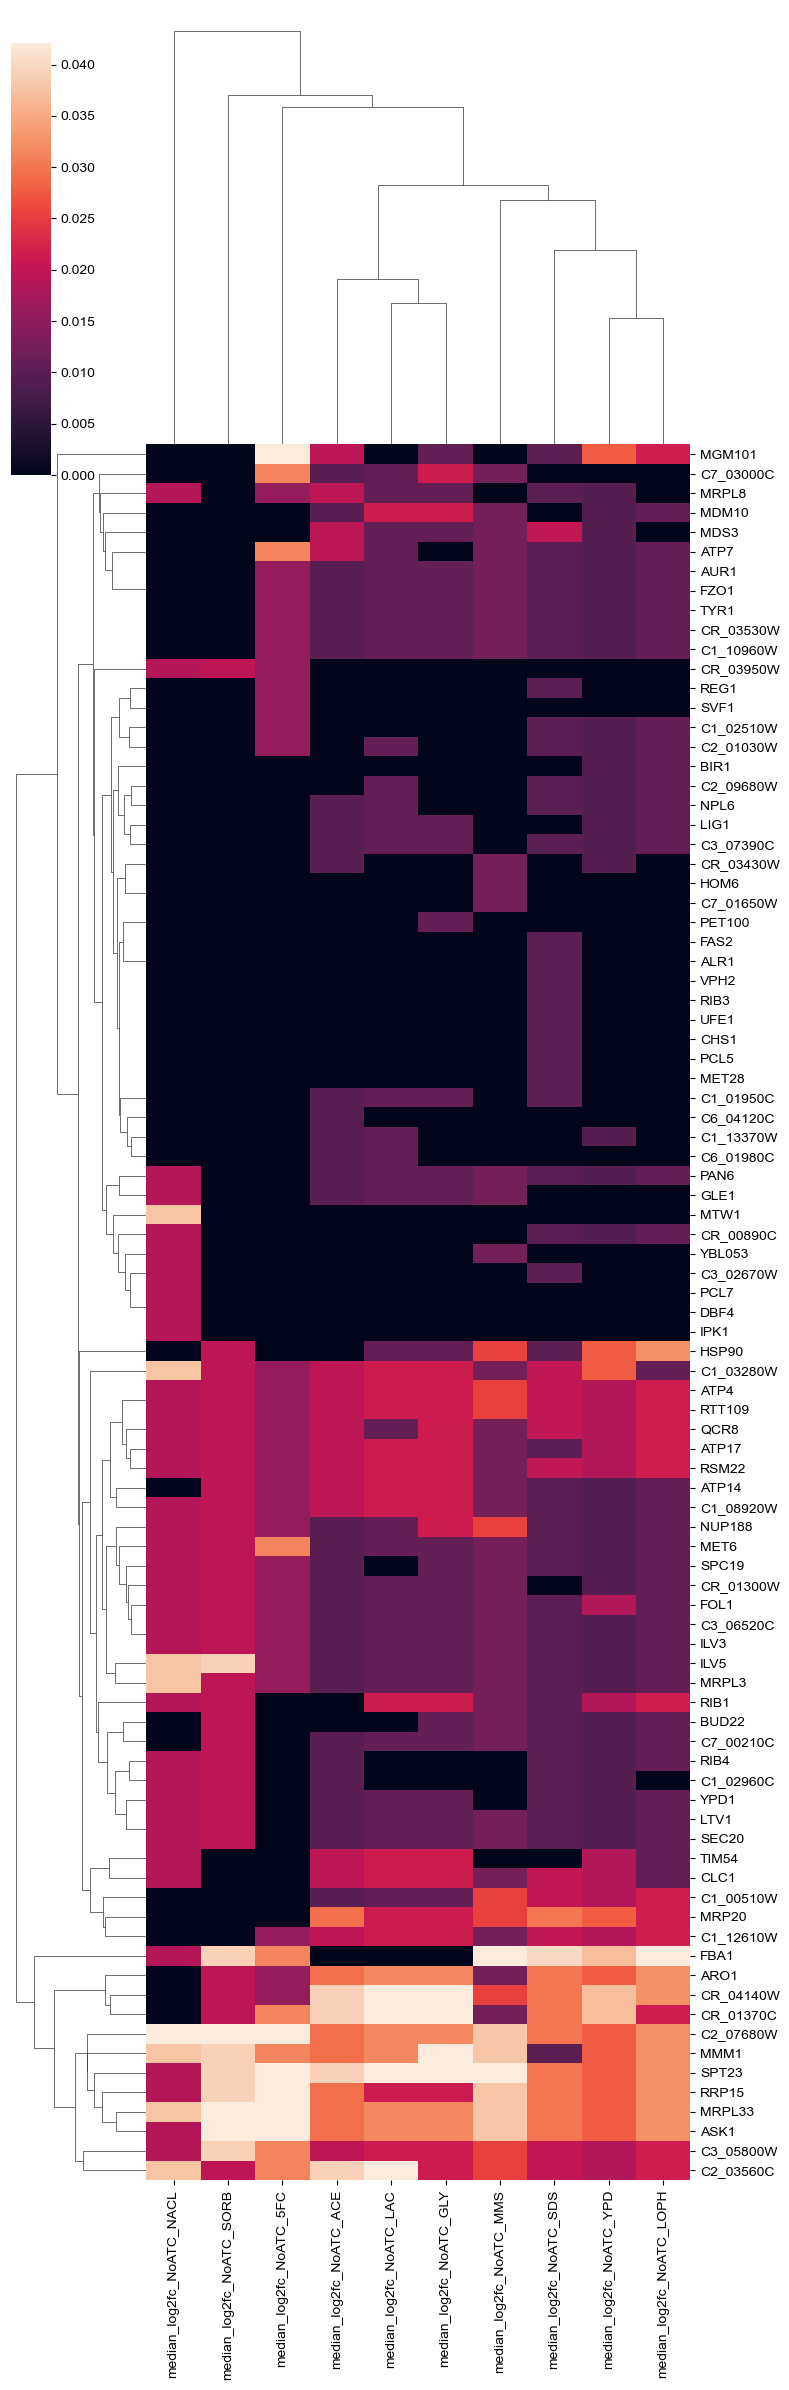

In [59]:
clustermap = sns.clustermap(hit_df_no_TUN, yticklabels=True, robust=True,figsize=(8,24))

Y_labels = [t.get_text() for t in clustermap.ax_heatmap.yaxis.get_majorticklabels()]
X_labels = [t.get_text() for t in clustermap.ax_heatmap.xaxis.get_majorticklabels()]


In [60]:
env_gene_dict = {}

gene_counter = Counter()

for condition in range(0,11):
    no_ATC_index = list(noATC_stats_df.index)[condition]
    print(no_ATC_index)
    threshold_no_ATC = noATC_stats_df.at[no_ATC_index, 'threshold']
    
    no_atc_hit_indexes = list(sgRNA_df[(sgRNA_df[no_ATC_index]<threshold_no_ATC)&(is_test)].index)

    for x in sgRNA_df.loc[no_atc_hit_indexes]['alias'].unique():
        gene_counter[x]+=1
    
    env_gene_dict[no_ATC_index] = sgRNA_df.loc[no_atc_hit_indexes]['alias'].unique()

median_log2fc_NoATC_YPD
median_log2fc_NoATC_LAC
median_log2fc_NoATC_GLY
median_log2fc_NoATC_ACE
median_log2fc_NoATC_NACL
median_log2fc_NoATC_SORB
median_log2fc_NoATC_LOPH
median_log2fc_NoATC_SDS
median_log2fc_NoATC_5FC
median_log2fc_NoATC_TUN
median_log2fc_NoATC_MMS


In [61]:
all_gene_list = []

gene_cdn_dict_of_dict = {}

for cdn in env_gene_dict.keys():
    gene_list = env_gene_dict[cdn]

    for gene in gene_list:
        if gene not in all_gene_list:
            all_gene_list.append(gene)

for gene in all_gene_list:
    gene_hit_dict = {}
    for cdn in env_gene_dict.keys():
        cdn_name = cdn.split('_')[3]
        if gene in env_gene_dict[cdn]:
            gene_hit_dict[cdn_name] = 1
        else:
            gene_hit_dict[cdn_name] = 0
            
    gene_cdn_dict_of_dict[gene] = gene_hit_dict

cdn_hit_df = pd.DataFrame.from_dict(gene_cdn_dict_of_dict).T


In [62]:
gene_hit_counts_dict_no_norm = {}

for condition in range(0,11):
    no_ATC_index = list(noATC_stats_df.index)[condition]
    threshold_no_ATC = noATC_stats_df.at[no_ATC_index, 'threshold']
    
    gene_list = sgRNA_df[is_test&(sgRNA_df[no_ATC_index]<threshold_no_ATC)]['alias'].value_counts()
    
    gene_hit_counts_dict_no_norm[no_ATC_index] = gene_list
    
    print(no_ATC_index, threshold_no_ATC, len(sgRNA_df[is_test&(sgRNA_df[no_ATC_index]<threshold_no_ATC)]))

pd.DataFrame(gene_hit_counts_dict_no_norm).fillna(0).to_csv('./conditions_hit_table_n_guides.csv', sep=',')

median_log2fc_NoATC_YPD -1.4029148345962223 108
median_log2fc_NoATC_LAC -0.9842570558628232 95
median_log2fc_NoATC_GLY -0.9078560591681946 95
median_log2fc_NoATC_ACE -1.2698725797435646 102
median_log2fc_NoATC_NACL -5.47207838129719 53
median_log2fc_NoATC_SORB -4.07254708531998 51
median_log2fc_NoATC_LOPH -1.6791209710527575 93
median_log2fc_NoATC_SDS -1.6807095729349957 100
median_log2fc_NoATC_5FC -2.226640214532156 64
median_log2fc_NoATC_TUN -1.9314562476036237 33
median_log2fc_NoATC_MMS -1.1400543473287854 79


In [63]:
heatmap_count_df = pd.DataFrame(gene_hit_counts_dict_no_norm)[[x for x in gene_hit_counts_dict_no_norm.keys() if x != 'median_log2fc_NoATC_TUN']].fillna(0).T
heatmap_count_df

alias,ALR1,ARO1,ASK1,ATP14,ATP17,ATP4,ATP7,AUR1,BIR1,BUD22,...,SEC20,SPC19,SPT23,SVF1,TIM54,TYR1,UFE1,VPH2,YBL053,YPD1
median_log2fc_NoATC_YPD,0.0,3.0,3.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,...,1.0,1.0,3.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0
median_log2fc_NoATC_LAC,0.0,3.0,3.0,2.0,2.0,2.0,1.0,1.0,0.0,0.0,...,1.0,0.0,4.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0
median_log2fc_NoATC_GLY,0.0,3.0,3.0,2.0,2.0,2.0,0.0,1.0,0.0,1.0,...,1.0,1.0,4.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0
median_log2fc_NoATC_ACE,0.0,3.0,3.0,2.0,2.0,2.0,2.0,1.0,0.0,0.0,...,1.0,1.0,4.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0
median_log2fc_NoATC_NACL,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
median_log2fc_NoATC_SORB,0.0,1.0,3.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
median_log2fc_NoATC_LOPH,0.0,3.0,3.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,...,1.0,1.0,3.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
median_log2fc_NoATC_SDS,1.0,3.0,3.0,1.0,1.0,2.0,1.0,1.0,0.0,1.0,...,1.0,1.0,3.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
median_log2fc_NoATC_5FC,0.0,1.0,3.0,1.0,1.0,1.0,2.0,1.0,0.0,0.0,...,0.0,1.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
median_log2fc_NoATC_MMS,0.0,1.0,3.0,1.0,1.0,2.0,1.0,1.0,0.0,1.0,...,1.0,1.0,4.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [64]:
recurrent_heatmap_count_df = heatmap_count_df.loc[:, heatmap_count_df.to_numpy().sum(axis=0) >1]

73

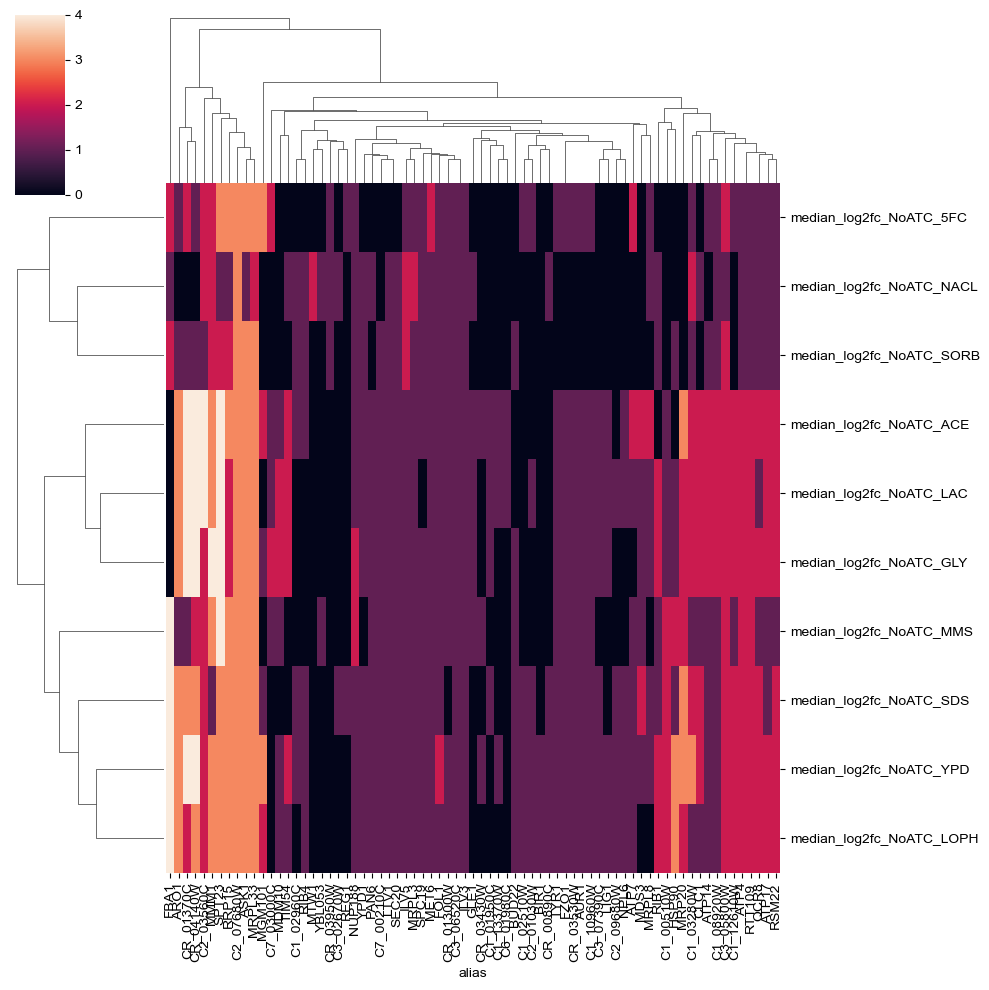

In [65]:
clustermap = sns.clustermap(recurrent_heatmap_count_df, xticklabels=True)
Y_labels = [t.get_text() for t in clustermap.ax_heatmap.yaxis.get_majorticklabels()]
X_labels = [t.get_text() for t in clustermap.ax_heatmap.xaxis.get_majorticklabels()]
len(X_labels)

In [66]:
label_list = []

for label in X_labels:
    if len(label) >=7:
        chrom, sys_name = label.split('_')
        plot_label = "$\\it{"+chrom+"}$"+"_"+"$\\it{"+sys_name+"}$"
        label_list.append(plot_label)

    else:
        plot_label = "$\\it{"+label+"}$"
        label_list.append(plot_label)

In [67]:
label_list

['$\\it{FBA1}$',
 '$\\it{ARO1}$',
 '$\\it{CR}$_$\\it{01370C}$',
 '$\\it{CR}$_$\\it{04140W}$',
 '$\\it{C2}$_$\\it{03560C}$',
 '$\\it{MMM1}$',
 '$\\it{SPT23}$',
 '$\\it{RRP15}$',
 '$\\it{C2}$_$\\it{07680W}$',
 '$\\it{ASK1}$',
 '$\\it{MRPL33}$',
 '$\\it{MGM101}$',
 '$\\it{C7}$_$\\it{03000C}$',
 '$\\it{MDM10}$',
 '$\\it{TIM54}$',
 '$\\it{C1}$_$\\it{02960C}$',
 '$\\it{RIB4}$',
 '$\\it{MTW1}$',
 '$\\it{YBL053}$',
 '$\\it{CR}$_$\\it{03950W}$',
 '$\\it{C3}$_$\\it{02670W}$',
 '$\\it{REG1}$',
 '$\\it{NUP188}$',
 '$\\it{YPD1}$',
 '$\\it{PAN6}$',
 '$\\it{C7}$_$\\it{00210C}$',
 '$\\it{LTV1}$',
 '$\\it{SEC20}$',
 '$\\it{ILV5}$',
 '$\\it{MRPL3}$',
 '$\\it{SPC19}$',
 '$\\it{MET6}$',
 '$\\it{FOL1}$',
 '$\\it{CR}$_$\\it{01300W}$',
 '$\\it{C3}$_$\\it{06520C}$',
 '$\\it{ILV3}$',
 '$\\it{GLE1}$',
 '$\\it{CR}$_$\\it{03430W}$',
 '$\\it{C1}$_$\\it{01950C}$',
 '$\\it{C1}$_$\\it{13370W}$',
 '$\\it{C6}$_$\\it{01980C}$',
 '$\\it{BUD22}$',
 '$\\it{C1}$_$\\it{02510W}$',
 '$\\it{C2}$_$\\it{01030W}$',
 '$\\it{BIR1}$'

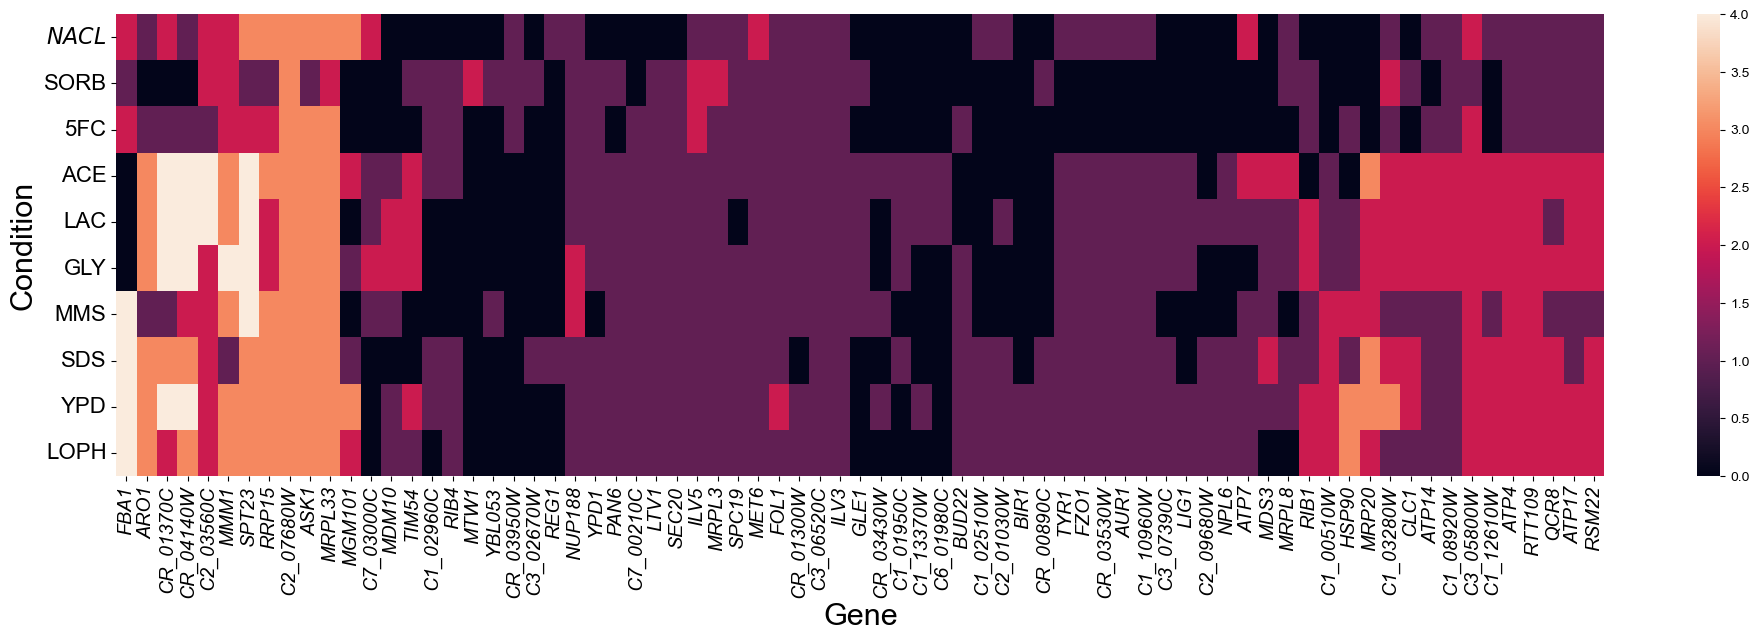

In [68]:
plt.figure(figsize=(24,6))

sns.heatmap(recurrent_heatmap_count_df.loc[Y_labels][X_labels], 
            yticklabels=[r'$\it{NACL}$', 'SORB', '5FC', 'ACE', 'LAC', 'GLY', 'MMS', 'SDS', 'YPD', 'LOPH'])


plt.yticks(rotation=0, fontsize=16)
plt.xticks(rotation=90, style='italic', fontsize=14)


plt.ylabel('Condition', fontsize=22)
plt.xlabel('Gene', fontsize=22)

plt.savefig('./figures/noTUN_heatmap_hor_recur.svg', format='svg', dpi=300)

In [69]:
for x in gene_counter.keys():
    if gene_counter[x] >= 7:
        print (x, gene_counter[x])

C1_00510W 8
MRP20 7
C1_03280W 10
SPC19 9
RSM22 10
YPD1 8
ATP7 7
MRPL3 11
C1_08920W 10
NUP188 11
C1_10960W 9
C1_12610W 9
C2_03560C 10
QCR8 10
ATP4 10
ATP14 9
C2_07680W 11
RRP15 10
SPT23 11
MRPL33 11
C3_05800W 11
C3_06520C 10
MMM1 11
ARO1 9
ASK1 11
FBA1 8
TYR1 9
CLC1 8
FZO1 8
FOL1 11
AUR1 8
ILV3 11
ILV5 11
SEC20 9
C7_00210C 8
ATP17 10
RTT109 11
CR_01300W 9
CR_01370C 9
MET6 11
PAN6 8
RIB1 8
CR_03530W 9
CR_04140W 10
MRPL8 7
LTV1 9
HSP90 7


In [70]:
noATC_stats_df.index

Index(['median_log2fc_NoATC_YPD', 'median_log2fc_NoATC_LAC',
       'median_log2fc_NoATC_GLY', 'median_log2fc_NoATC_ACE',
       'median_log2fc_NoATC_NACL', 'median_log2fc_NoATC_SORB',
       'median_log2fc_NoATC_LOPH', 'median_log2fc_NoATC_SDS',
       'median_log2fc_NoATC_5FC', 'median_log2fc_NoATC_TUN',
       'median_log2fc_NoATC_MMS'],
      dtype='object')

In [71]:
no_tun_list = ['median_log2fc_NoATC_YPD', 
               'median_log2fc_NoATC_LAC', 'median_log2fc_NoATC_GLY', 'median_log2fc_NoATC_ACE',
               'median_log2fc_NoATC_NACL', 'median_log2fc_NoATC_SORB',
               'median_log2fc_NoATC_LOPH', 'median_log2fc_NoATC_SDS',
               'median_log2fc_NoATC_5FC', 'median_log2fc_NoATC_MMS']

In [72]:
gene_counter_no_tun = Counter()

for condition in range(0,10):
    no_ATC_index = no_tun_list[condition]
    print(no_ATC_index)
    threshold_no_ATC = noATC_stats_df.at[no_ATC_index, 'threshold']
    
    no_atc_hit_indexes = list(sgRNA_df[(sgRNA_df[no_ATC_index]<threshold_no_ATC)&(is_test)].index)

    for x in sgRNA_df.loc[no_atc_hit_indexes]['alias'].unique():
        gene_counter_no_tun[x]+=1
    
len(gene_counter_no_tun)

median_log2fc_NoATC_YPD
median_log2fc_NoATC_LAC
median_log2fc_NoATC_GLY
median_log2fc_NoATC_ACE
median_log2fc_NoATC_NACL
median_log2fc_NoATC_SORB
median_log2fc_NoATC_LOPH
median_log2fc_NoATC_SDS
median_log2fc_NoATC_5FC
median_log2fc_NoATC_MMS


89

In [73]:
gene_counter_no_tun

Counter({'C1_03280W': 10,
         'RSM22': 10,
         'MRPL3': 10,
         'C1_08920W': 10,
         'NUP188': 10,
         'C2_03560C': 10,
         'QCR8': 10,
         'ATP4': 10,
         'C2_07680W': 10,
         'RRP15': 10,
         'SPT23': 10,
         'MRPL33': 10,
         'C3_05800W': 10,
         'C3_06520C': 10,
         'MMM1': 10,
         'ASK1': 10,
         'FOL1': 10,
         'ILV3': 10,
         'ILV5': 10,
         'ATP17': 10,
         'RTT109': 10,
         'MET6': 10,
         'SPC19': 9,
         'ATP14': 9,
         'ARO1': 9,
         'SEC20': 9,
         'CR_01300W': 9,
         'CR_01370C': 9,
         'CR_04140W': 9,
         'LTV1': 9,
         'YPD1': 8,
         'C1_10960W': 8,
         'C1_12610W': 8,
         'TYR1': 8,
         'CLC1': 8,
         'FZO1': 8,
         'AUR1': 8,
         'C7_00210C': 8,
         'PAN6': 8,
         'RIB1': 8,
         'CR_03530W': 8,
         'C1_00510W': 7,
         'MRP20': 7,
         'ATP7': 7,
         'FBA

In [74]:
len(gene_counter)

89

In [75]:
[x/96 for x in gene_counter_no_tun.values()]

[0.07291666666666667,
 0.07291666666666667,
 0.041666666666666664,
 0.0625,
 0.052083333333333336,
 0.10416666666666667,
 0.09375,
 0.10416666666666667,
 0.0625,
 0.08333333333333333,
 0.07291666666666667,
 0.10416666666666667,
 0.10416666666666667,
 0.10416666666666667,
 0.08333333333333333,
 0.08333333333333333,
 0.03125,
 0.052083333333333336,
 0.052083333333333336,
 0.10416666666666667,
 0.10416666666666667,
 0.0625,
 0.10416666666666667,
 0.09375,
 0.10416666666666667,
 0.10416666666666667,
 0.041666666666666664,
 0.10416666666666667,
 0.10416666666666667,
 0.10416666666666667,
 0.10416666666666667,
 0.0625,
 0.0625,
 0.10416666666666667,
 0.09375,
 0.10416666666666667,
 0.07291666666666667,
 0.08333333333333333,
 0.08333333333333333,
 0.08333333333333333,
 0.10416666666666667,
 0.08333333333333333,
 0.10416666666666667,
 0.10416666666666667,
 0.09375,
 0.08333333333333333,
 0.052083333333333336,
 0.0625,
 0.10416666666666667,
 0.10416666666666667,
 0.0625,
 0.041666666666666664,


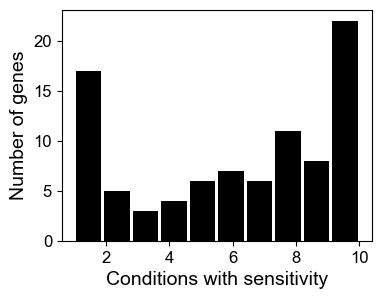

In [76]:
plt.figure(figsize=(4,3))


plt.hist(gene_counter_no_tun.values(), bins = 10, lw=3, color='k',rwidth=0.9)



plt.xlabel('Conditions with sensitivity', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)



plt.ylabel('Number of genes', fontsize=14)


plt.savefig('./figures/gene_hit_cumul_no_TUN.svg', format='svg', dpi=300, bbox_inches='tight')


0
0
1


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 31.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 37.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


1
2
2
3


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 41.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 34.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 48.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 37.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


3


/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 44.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 37.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/phil/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 48.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


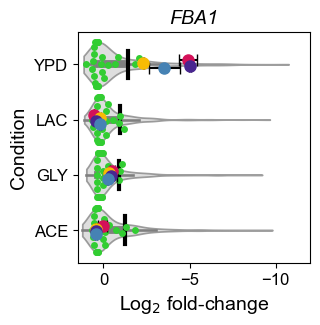

In [77]:
plt.figure(figsize=(3,3))

test_guide_list = [274,275,276,277]

y_loc = 0

for condition in ['median_log2fc_NoATC_YPD', 'median_log2fc_NoATC_LAC', 'median_log2fc_NoATC_GLY', 'median_log2fc_NoATC_ACE']:
    
    mad_col = condition.replace('median', 'mad')
    
    print(y_loc)
    sns.swarmplot(x=sgRNA_df[is_control][condition], y = y_loc, zorder=8, color='limegreen', orient='h')
    sns.violinplot(x=sgRNA_df[is_test][condition], y = y_loc, orient='h', color='lightgrey', cut=0, alpha=0.75)
    print(y_loc)
    plt.plot([noATC_stats_df.at[condition, 'threshold'],noATC_stats_df.at[condition, 'threshold'] ], [(y_loc-0.25), (y_loc+0.25)], 'k-', lw=3)
    
    plt.errorbar(sgRNA_df.at[test_guide_list[0], condition], y_loc-0.075, 
             xerr=sgRNA_df.at[test_guide_list[0], mad_col], 
             color='#d41159', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[1],condition], y_loc-0.025, 
             xerr=sgRNA_df.at[test_guide_list[1],mad_col], 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[2],condition], y_loc+0.025, 
             xerr=sgRNA_df.at[test_guide_list[2],mad_col], 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[3],condition], y_loc+0.075, 
             xerr=sgRNA_df.at[test_guide_list[3],mad_col], 
             color='steelblue', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

    
    y_loc+=1

plt.xticks(fontsize=12)    
plt.yticks(range(0,4), ['YPD', 'LAC', 'GLY', 'ACE'], fontsize=12)
plt.ylabel('Condition', fontsize=14)

plt.xlabel('Log$_{2}$ fold-change', fontsize=14)

#plt.legend([str(x) for x in test_guide_list], loc='upper right', bbox_to_anchor=(1.25, 0.5))

plt.title('FBA1', fontsize=14, style='italic')

plt.xlim(1.5,-12)

plt.savefig('./figures/FBA1_violinplot_fig.svg', format='svg', dpi=300)

In [88]:
sgRNA_df.to_csv('./Table_S7.csv', sep=',')